In [ ]:
# vis_comparison_glm_vs_gpt52.py
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
import seaborn as sns

def setup_style(double_column: bool = True):
    if double_column:
        fig_w_in = 14
        fig_h_in = 4
    else:
        fig_w_in = 3.54
        fig_h_in = 3.0

    sns.set_theme(style="white", context="paper", font_scale=1.0)
    plt.rcParams.update({
        'figure.figsize': (fig_w_in, fig_h_in),
        'figure.dpi': 600,
        'savefig.dpi': 600,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.02,
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans', 'Liberation Sans'],
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        "svg.fonttype":'none',
        'font.size': 12,
        'axes.labelsize': 12,
        'axes.titlesize': 12,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'legend.fontsize': 12,
        'legend.title_fontsize': 12,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'xtick.direction': 'out',
        'ytick.direction': 'out',
        'xtick.major.width': 0.4,
        'ytick.major.width': 0.4,
        'xtick.minor.width': 0.3,
        'ytick.minor.width': 0.3,
        'xtick.major.size': 2.5,
        'ytick.major.size': 2.5,
        'xtick.minor.size': 2.0,
        'ytick.minor.size': 2.0,
        'axes.linewidth': 0.5,
        'patch.edgecolor': 'none',
        'patch.linewidth': 0.0,
        'axes.grid': False,
        'figure.autolayout': False,
        'mathtext.default': 'regular',
        'axes.titlepad': 4,
        'axes.labelpad': 3,
    })

setup_style(double_column=True)

DATASET_NAME_MAP = {
    'appendicitis': 'Appendicitis',
    'cholecystitis': 'Cholecystitis',
    'diverticulitis': 'Diverticulitis',
    'pancreatitis': 'Pancreatitis',
    'pneumonia': 'Pneumonia',
    'pulmonary_embolism': 'Pulmonary Embolism',
    'uti': 'UTI',
}
ALL_DATASETS = list(DATASET_NAME_MAP.keys())

PLOTS_BASE_DIR = '/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.3/benchmark'
RAW_AGGREGATED_DIR_GLM = '/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/63/5runs/63.3'
RAW_AGGREGATED_DIR_GPT52 = '/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/65/65.3'

def load_runs(agg_dir: str, label: str) -> pd.DataFrame:
    all_runs = []
    for internal_name in ALL_DATASETS:
        agg_file_path = os.path.join(agg_dir, f"{internal_name}_multi_run.jsonl")
        if not os.path.exists(agg_file_path):
            print(f"  警告: 文件 {agg_file_path} 未找到，跳过 {internal_name}。")
            continue
        df_agg = pd.read_json(agg_file_path, lines=True)
        if df_agg.empty or 'runs' not in df_agg.columns:
            continue
        num_runs = len(df_agg['runs'].iloc[0]) if not df_agg.empty else 0
        for i in range(num_runs):
            run_col = f'run_{i+1}_decision'
            df_agg[run_col] = df_agg['runs'].apply(lambda runs: runs[i]['decision'] if len(runs) > i else None)
            accuracy = df_agg[run_col].mean() * 100
            all_runs.append({
                'Dataset': DATASET_NAME_MAP[internal_name],
                'Accuracy': accuracy,
                'Run': i + 1,
                'Model': label,
            })

    all_agg_dfs = []
    for internal_name in ALL_DATASETS:
        fp = os.path.join(agg_dir, f"{internal_name}_multi_run.jsonl")
        if os.path.exists(fp):
            all_agg_dfs.append(pd.read_json(fp, lines=True))
    if all_agg_dfs:
        df_overall = pd.concat(all_agg_dfs, ignore_index=True)
        num_runs_overall = len(df_overall['runs'].iloc[0]) if not df_overall.empty else 0
        for i in range(num_runs_overall):
            run_col = f'run_{i+1}_decision'
            df_overall[run_col] = df_overall['runs'].apply(lambda runs: runs[i]['decision'] if len(runs) > i else None)
            accuracy = df_overall[run_col].mean() * 100
            all_runs.append({
                'Dataset': 'Overall',
                'Accuracy': accuracy,
                'Run': i + 1,
                'Model': label,
            })
    return pd.DataFrame(all_runs)

print('Loading GLM-4.5-Air runs...')
df_glm = load_runs(RAW_AGGREGATED_DIR_GLM, 'Our Agent (GLM-4.5-Air)')
print('Loading GPT-5.2 runs...')
df_gpt52 = load_runs(RAW_AGGREGATED_DIR_GPT52, 'Our Agent (GPT-5.2)')

df_combined = pd.concat([df_glm, df_gpt52], ignore_index=True)
df_combined['Dataset'] = df_combined['Dataset'].astype(str).str.strip()
dataset_order = ['Overall'] + [name for name in DATASET_NAME_MAP.values()
                               if name in df_combined['Dataset'].unique()]
df_combined['Dataset'] = pd.Categorical(df_combined['Dataset'], categories=dataset_order, ordered=True)
df_combined = df_combined.sort_values('Dataset')

fig, ax = plt.subplots()
color_palette = {
    'Our Agent (GLM-4.5-Air)': '#3B91C2',
    'Our Agent (GPT-5.2)': '#D4BAC7',
}
ax = sns.barplot(
    data=df_combined,
    x='Dataset',
    y='Accuracy',
    hue='Model',
    palette=color_palette,
    errorbar='sd',
    capsize=0,
    err_kws={'linewidth': 0.75},
    width=0.75,
    linewidth=0,
    edgecolor='none',
    ax=ax,
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(0.5)

ax.tick_params(axis='both', which='major', width=0.5, length=2.5,
               direction='out', top=False, right=False, bottom=True, left=True)

ax.set_xlabel('')
ax.tick_params(axis='x', labelrotation=30)
ax.set_ylabel('Diagnostic Accuracy (%)')
ymin = max(0, df_combined['Accuracy'].min() - 5)
ax.set_ylim(ymin, 100.0)
ax.yaxis.set_major_locator(MultipleLocator(10))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles, labels=labels, title='Model',
    bbox_to_anchor=(1.02, 0.7),
    loc='upper left',
    frameon=False,
    handlelength=1.0, handleheight=1.0,
)

plt.tight_layout(rect=[0, 0, 0.86, 1])
os.makedirs(PLOTS_BASE_DIR, exist_ok=True)
out_svg = os.path.join(PLOTS_BASE_DIR, 'accuracy_comparison_glm_vs_gpt52.svg')
out_png = os.path.join(PLOTS_BASE_DIR, 'accuracy_comparison_glm_vs_gpt52.png')
out_pdf = os.path.join(PLOTS_BASE_DIR, 'accuracy_comparison_glm_vs_gpt52.pdf')
plt.savefig(out_svg, format='svg', bbox_inches='tight')
plt.savefig(out_png, format='png', bbox_inches='tight')
plt.savefig(out_pdf, format='pdf', bbox_inches='tight')
# plt.close()
print(f'GLM vs GPT-5.2 图表已保存到: {PLOTS_BASE_DIR}')


正在加载 GPT-OSS ...
正在加载 GLM-4.5-Air ...
正在加载 GLM-5 ...
正在加载 Qwen-3.5 ...
正在加载 GPT-5.2 ...
accuracy 汇总已保存到: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/aidoc_benchmark/accuracy_summary_multi_models.csv
多模型分组条形图已保存到: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/aidoc_benchmark


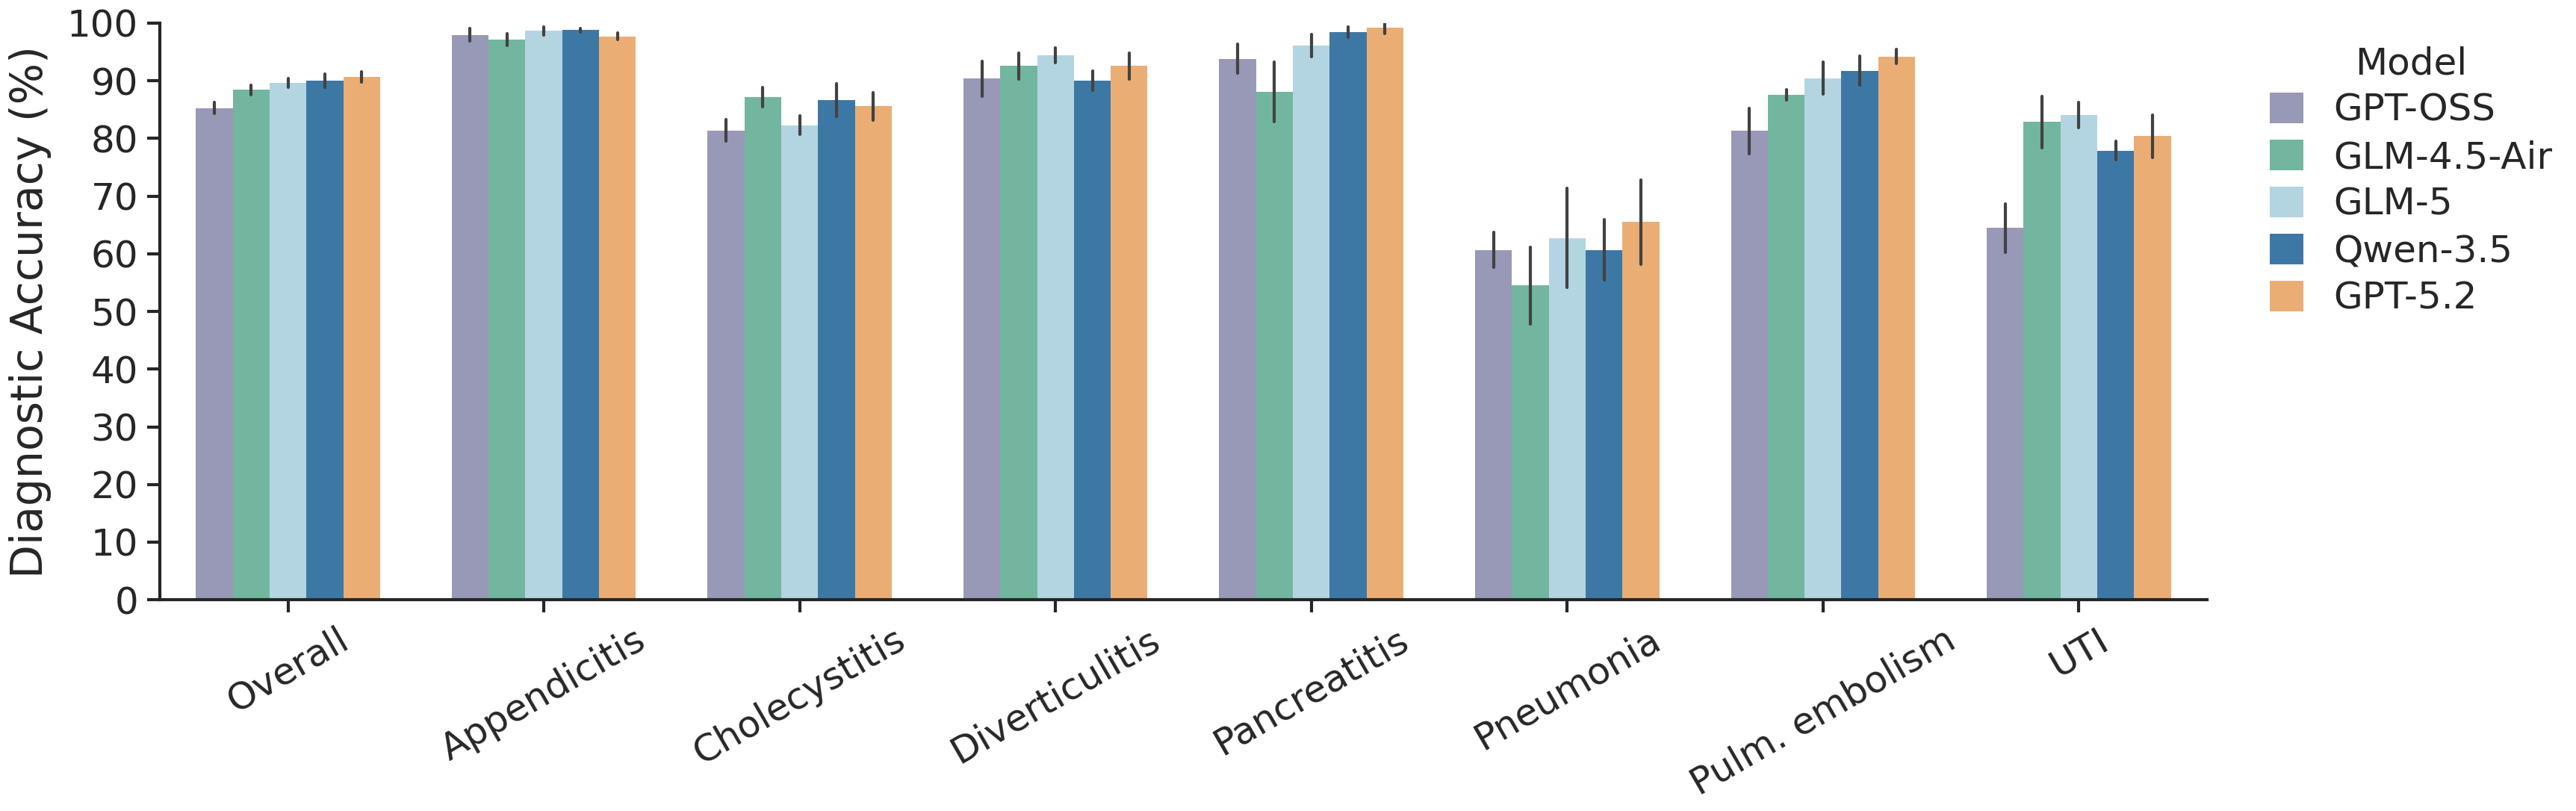

In [ ]:
# vis_comparison_multi_models.py
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
import seaborn as sns

# ========== 0) Style ==========
def setup_style(double_column: bool = True):
    if double_column:
        fig_w_in = 7.09
        fig_h_in = 2.2 * 0.9
    else:
        fig_w_in = 3.46
        fig_h_in = 2.0

    sns.set_theme(style="white", context="paper", font_scale=1.0)

    plt.rcParams.update({
        "figure.figsize": (fig_w_in, fig_h_in),
        "figure.dpi": 600,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,

        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "Liberation Sans"],
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype":'none',

        "font.size": 7,
        "axes.labelsize": 7,
        "axes.titlesize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "legend.fontsize": 6,
        "legend.title_fontsize": 6,

        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.width": 0.5,
        "ytick.major.width": 0.5,
        "xtick.minor.width": 0.4,
        "ytick.minor.width": 0.4,
        "xtick.major.size": 2.0,
        "ytick.major.size": 2.0,
        "xtick.minor.size": 1.5,
        "ytick.minor.size": 1.5,
        "axes.linewidth": 0.5,
        "patch.edgecolor": "none",
        "patch.linewidth": 0.0,

        "axes.grid": False,
        "figure.autolayout": False,
        "mathtext.default": "regular",
        "axes.titlepad": 3,
        "axes.labelpad": 2.5,
    })

setup_style(double_column=True)

# ========== 1) Constants and paths ==========
DATASET_NAME_MAP = {
    "appendicitis": "Appendicitis",
    "cholecystitis": "Cholecystitis",
    "diverticulitis": "Diverticulitis",
    "pancreatitis": "Pancreatitis",
    "pneumonia": "Pneumonia",
    "pulmonary_embolism": "Pulm. embolism",
    "uti": "UTI",
}
ALL_DATASETS = list(DATASET_NAME_MAP.keys())

PLOTS_BASE_DIR = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/aidoc_benchmark"

MODELS = [
    {
        "label": "GPT-OSS",
        "dir": "/mnt/bulk-uranus/lizhang/LiWorkSpace/data/evaluation/100/100.10",
        "color": "#9294BB", #"#155590", #"#B6B3D6", #"#917BBD", #"#B19CCB", 
    },
    {
        "label": "GLM-4.5-Air",
        "dir": "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/63/5runs/63.10",
        "color":"#66c2a4", #"#60b0b7", #"#bbe1f8", #"#354E6B", #"#46788E",
    },

    {
        "label": "GLM-5",
        "dir": "/mnt/bulk-uranus/lizhang/LiWorkSpace/data/evaluation/80/80.10",
        "color": "#abd9e9", #"#D5EDF9", #"#EEAC90", #, #"#4182A4", #"#E58B7B",
    },
    {
        "label": "Qwen-3.5",
        "dir": "/mnt/bulk-uranus/lizhang/LiWorkSpace/data/evaluation/82/82.10",
        "color": "#2c7bb6", 
    },
    {
        "label": "GPT-5.2",
        "dir": "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/65/65.10",
        "color": "#fdae61",
    },
]

# ========== 2) Load multiple runs for one model ==========
def load_model_runs(model_label, raw_dir):
    all_runs_data = []

    # Individual subdatasets
    for internal_name in ALL_DATASETS:
        agg_file_path = os.path.join(raw_dir, f"{internal_name}_multi_run.jsonl")
        if not os.path.exists(agg_file_path):
            print(f"  警告: 文件 {agg_file_path} 未找到，跳过 {internal_name}")
            continue

        df_agg = pd.read_json(agg_file_path, lines=True)
        if df_agg.empty or "runs" not in df_agg.columns:
            continue

        num_runs = len(df_agg["runs"].iloc[0])
        for i in range(num_runs):
            run_col = f"run_{i+1}_decision"
            df_agg[run_col] = df_agg["runs"].apply(
                lambda runs: runs[i]["decision"] if len(runs) > i else None
            )
            accuracy = df_agg[run_col].mean() * 100
            all_runs_data.append({
                "Dataset": DATASET_NAME_MAP[internal_name],
                "Accuracy": accuracy,
                "Run": i + 1,
                "Model": model_label,
            })

    # Overall
    all_agg_dfs = []
    for internal_name in ALL_DATASETS:
        fp = os.path.join(raw_dir, f"{internal_name}_multi_run.jsonl")
        if os.path.exists(fp):
            all_agg_dfs.append(pd.read_json(fp, lines=True))

    if all_agg_dfs:
        df_overall_agg = pd.concat(all_agg_dfs, ignore_index=True)
        num_runs_overall = len(df_overall_agg["runs"].iloc[0])

        for i in range(num_runs_overall):
            run_col = f"run_{i+1}_decision"
            df_overall_agg[run_col] = df_overall_agg["runs"].apply(
                lambda runs: runs[i]["decision"] if len(runs) > i else None
            )
            accuracy = df_overall_agg[run_col].mean() * 100
            all_runs_data.append({
                "Dataset": "Overall",
                "Accuracy": accuracy,
                "Run": i + 1,
                "Model": model_label,
            })

    return pd.DataFrame(all_runs_data)

# ========== 3) Aggregate multiple models ==========
all_model_dfs = []

for model_cfg in MODELS:
    print(f"正在加载 {model_cfg['label']} ...")
    df_model = load_model_runs(model_cfg["label"], model_cfg["dir"])
    if not df_model.empty:
        all_model_dfs.append(df_model)

if not all_model_dfs:
    raise ValueError("没有成功加载任何 model 的结果，请检查路径。")

df_combined = pd.concat(all_model_dfs, ignore_index=True)

dataset_order = ["Overall"] + [name for name in DATASET_NAME_MAP.values()]
df_combined["Dataset"] = df_combined["Dataset"].astype(str).str.strip()
df_combined["Dataset"] = pd.Categorical(
    df_combined["Dataset"],
    categories=dataset_order,
    ordered=True
)
df_combined = df_combined.sort_values("Dataset")

model_order = [m["label"] for m in MODELS]

df_combined["Model"] = pd.Categorical(
    df_combined["Model"],
    categories=model_order,
    ordered=True
)

# ========== Additional export: accuracy for each model (% +/- SD) ==========
df_summary = (
    df_combined
    .groupby(["Dataset", "Model"], observed=True)["Accuracy"]
    .agg(["mean", "std"])
    .reset_index()
    .rename(columns={"mean": "Accuracy_mean", "std": "Accuracy_sd"})
)

# Keep two decimal places
df_summary["Accuracy_mean"] = df_summary["Accuracy_mean"].round(2)
df_summary["Accuracy_sd"] = df_summary["Accuracy_sd"].round(2)

# Create display columns: xx.xx +/- yy.yy
df_summary["Accuracy (% ± SD)"] = (
    df_summary["Accuracy_mean"].map(lambda x: f"{x:.2f}")
    + " ± "
    + df_summary["Accuracy_sd"].fillna(0).map(lambda x: f"{x:.2f}")
)

summary_csv_path = os.path.join(PLOTS_BASE_DIR, "accuracy_summary_multi_models.csv")
df_summary.to_csv(summary_csv_path, index=False)

print(f"accuracy 汇总已保存到: {summary_csv_path}")


# ========== 4) Plot ==========
fig, ax = plt.subplots()
fig.subplots_adjust(left=0.08, right=0.98, bottom=0.22, top=0.95)

color_palette = {m["label"]: m["color"] for m in MODELS}

ax = sns.barplot(
    data=df_combined,
    x="Dataset",
    y="Accuracy",
    hue="Model",
    hue_order=model_order,
    palette=color_palette,
    errorbar="sd",
    capsize=0,
    err_kws={"linewidth": 0.5},
    width=0.72,
    linewidth=0,
    edgecolor="none",
    ax=ax,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(0.5)

ax.tick_params(
    axis="both",
    which="major",
    width=0.5,
    length=2.0,
    direction="out",
    top=False,
    right=False,
    bottom=True,
    left=True,
    pad=1.5,
)

ax.set_xlabel("")
ax.set_ylabel("Diagnostic Accuracy (%)")

ymin = max(0, df_combined["Accuracy"].min() - 5)
ax.set_ylim(0, 100.0)
ax.yaxis.set_major_locator(MultipleLocator(10))
ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))

ax.tick_params(axis="x", labelrotation=30)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=labels,
    title="Model",
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
    frameon=False,
    handlelength=0.9,
    handleheight=0.9,
    borderaxespad=0.2,
    labelspacing=0.3,
    columnspacing=0.8,
)

plt.tight_layout(rect=[0, 0, 0.84, 1])

# ========== 5) Save ==========
os.makedirs(PLOTS_BASE_DIR, exist_ok=True)

out_svg = os.path.join(PLOTS_BASE_DIR, "accuracy_comparison_multi_models.svg")
out_png = os.path.join(PLOTS_BASE_DIR, "accuracy_comparison_multi_models.png")
out_pdf = os.path.join(PLOTS_BASE_DIR, "accuracy_comparison_multi_models.pdf")

plt.savefig(out_svg, format="svg", bbox_inches="tight")
plt.savefig(out_png, format="png", bbox_inches="tight")
plt.savefig(out_pdf, format="pdf", bbox_inches="tight")

print(f"多模型分组条形图已保存到: {PLOTS_BASE_DIR}")
plt.show()
plt.close()


In [2]:
import numpy as np
import pandas as pd
from scipy.stats import t, friedmanchisquare


def bootstrap_accuracy_ci_from_runs(
    df_agg: pd.DataFrame,
    n_boot: int = 2000,
    ci: float = 95,
    random_state: int = 42,
):
    """
    df_agg: 一个 *_multi_run.jsonl 读进来的 dataframe
            必须包含 'runs' 列，每行对应一个 case
    返回:
        mean_accuracy, ci_low, ci_high
    """

    rng = np.random.default_rng(random_state)

    # Each case becomes one row, and each run becomes one decision (0/1) column
    decisions = []
    num_runs = max(len(runs) for runs in df_agg["runs"])

    for _, row in df_agg.iterrows():
        run_decisions = []
        runs = row["runs"]

        for i in range(num_runs):
            if i < len(runs) and isinstance(runs[i], dict):
                val = runs[i].get("effective_decision", runs[i].get("decision", None))
                run_decisions.append(np.nan if val is None else float(bool(val)))
            else:
                run_decisions.append(np.nan)

        decisions.append(run_decisions)

    decision_matrix = np.array(decisions, dtype=float)   # shape: (n_cases, n_runs)
    n_cases = decision_matrix.shape[0]

    # Raw mean accuracy: calculate accuracy for each run, then average across runs
    run_accs = np.nanmean(decision_matrix, axis=0)
    mean_accuracy = float(np.nanmean(run_accs) * 100)

    accuracy_sd = float(np.nanstd(run_accs * 100, ddof=1)) if np.sum(~np.isnan(run_accs)) > 1 else 0.0

    boot_means = []
    for _ in range(n_boot):
        sample_idx = rng.integers(0, n_cases, size=n_cases)
        sampled = decision_matrix[sample_idx, :]
        sampled_run_accs = np.nanmean(sampled, axis=0)
        boot_means.append(np.nanmean(sampled_run_accs) * 100)

    alpha = (100 - ci) / 2
    ci_low = float(np.percentile(boot_means, alpha))
    ci_high = float(np.percentile(boot_means, 100 - alpha))

    return mean_accuracy, accuracy_sd, ci_low, ci_high


def load_model_summary_with_case_bootstrap(model_label, raw_dir):
    rows = []

    for internal_name in ALL_DATASETS:
        agg_file_path = os.path.join(raw_dir, f"{internal_name}_multi_run.jsonl")
        if not os.path.exists(agg_file_path):
            continue

        df_agg = pd.read_json(agg_file_path, lines=True)
        if df_agg.empty or "runs" not in df_agg.columns:
            continue

        mean_acc, accuracy_sd, ci_low, ci_high = bootstrap_accuracy_ci_from_runs(df_agg)

        rows.append({
            "Dataset": DATASET_NAME_MAP[internal_name],
            "Model": model_label,
            "Accuracy_mean": mean_acc,
            "Accuracy_sd": accuracy_sd,
            "CI95_low": ci_low,
            "CI95_high": ci_high,
        })

    # Overall
    all_agg_dfs = []
    for internal_name in ALL_DATASETS:
        fp = os.path.join(raw_dir, f"{internal_name}_multi_run.jsonl")
        if os.path.exists(fp):
            all_agg_dfs.append(pd.read_json(fp, lines=True))

    if all_agg_dfs:
        df_overall = pd.concat(all_agg_dfs, ignore_index=True)
        mean_acc, accuracy_sd, ci_low, ci_high = bootstrap_accuracy_ci_from_runs(df_overall)
        rows.append({
            "Dataset": "Overall",
            "Model": model_label,
            "Accuracy_mean": mean_acc,
            "Accuracy_sd": accuracy_sd,
            "CI95_low": ci_low,
            "CI95_high": ci_high,
        })

    return pd.DataFrame(rows)


from scipy.stats import wilcoxon

def _case_mean_correct_by_dataset(raw_dir, internal_name, decision_key="decision"):
    fp = os.path.join(raw_dir, f"{internal_name}_multi_run.jsonl")
    if not os.path.exists(fp):
        return pd.DataFrame()

    df = pd.read_json(fp, lines=True)
    if df.empty or "runs" not in df.columns:
        return pd.DataFrame()

    rows = []
    for _, row in df.iterrows():
        vals = []
        for run in row["runs"]:
            if isinstance(run, dict):
                vals.append(np.nan if run.get(decision_key) is None else float(bool(run.get("effective_decision", run.get(decision_key, None)))))
        rows.append({
            "case_id": f"{internal_name}__{row.get('hadm_id')}",
            "Dataset": DATASET_NAME_MAP[internal_name],
            "mean_correct": np.nanmean(vals) if vals else np.nan,
        })

    return pd.DataFrame(rows)


def paired_temperature_comparison(
    dir_a,
    dir_b,
    label_a="T=0.01",
    label_b="T=0.3",
    decision_key="decision",
    n_boot=5000,
    random_state=42,
):
    rng = np.random.default_rng(random_state)

    all_pairs = []

    for internal_name in ALL_DATASETS:
        df_a = _case_mean_correct_by_dataset(dir_a, internal_name, decision_key=decision_key)
        df_b = _case_mean_correct_by_dataset(dir_b, internal_name, decision_key=decision_key)

        if df_a.empty or df_b.empty:
            continue

        merged = df_a.merge(
            df_b,
            on=["case_id", "Dataset"],
            suffixes=("_a", "_b"),
        ).dropna(subset=["mean_correct_a", "mean_correct_b"])

        if merged.empty:
            continue

        merged["diff"] = merged["mean_correct_a"] - merged["mean_correct_b"]
        all_pairs.append(merged)

    if not all_pairs:
        raise ValueError("No paired cases found between the two temperature directories.")

    df_pairs = pd.concat(all_pairs, ignore_index=True)

    diffs = df_pairs["diff"].to_numpy(dtype=float)
    n = len(diffs)

    # Effect size: paired mean accuracy difference in percentage points.
    observed_diff_pp = float(np.mean(diffs) * 100)

    # Paired case-level bootstrap CI.
    boot_diffs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot_diffs.append(np.mean(diffs[idx]) * 100)

    ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])

    # One-sided paired permutation test: H1 = label_a > label_b.
    # Under the null, signs of paired differences are exchangeable.
    perm_stats = []
    for _ in range(n_boot):
        signs = rng.choice([-1, 1], size=n)
        perm_stats.append(np.mean(diffs * signs) * 100)

    p_one_sided = float((np.sum(np.array(perm_stats) >= observed_diff_pp) + 1) / (n_boot + 1))

    # Optional nonparametric paired test for cross-check.
    try:
        wilcoxon_p = wilcoxon(diffs, alternative="greater", zero_method="wilcox").pvalue
    except ValueError:
        wilcoxon_p = np.nan

    result = pd.DataFrame([{
        "Comparison": f"{label_a} - {label_b}",
        "N_cases": n,
        "Accuracy_diff_pp": observed_diff_pp,
        "CI95_low_pp": float(ci_low),
        "CI95_high_pp": float(ci_high),
        "Permutation_p_one_sided": p_one_sided,
        "Wilcoxon_p_one_sided": wilcoxon_p,
    }])

    return result, df_pairs



===== Processing group: GPT-OSS =====
       Comparison  N_cases  Accuracy_diff_pp  CI95_low_pp  CI95_high_pp  \
0  T=0.01 - T=0.3      551            0.2541      -0.8348         1.343   

   Permutation_p_one_sided  Wilcoxon_p_one_sided  
0                   0.3401                0.4313  
T=0.01 vs T=0.3 paired test saved to: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/aidoc_benchmark/Eval_10/GPT_OSS_120B/temperature_T001_vs_T03_paired_test.csv
正在加载 T=0.01 ...
正在加载 T=0.3 ...
正在加载 T=0.6 ...
正在加载 T=0.9 ...
正在计算 bootstrap CI for T=0.01 ...
正在计算 bootstrap CI for T=0.3 ...
正在计算 bootstrap CI for T=0.6 ...
正在计算 bootstrap CI for T=0.9 ...
case-level bootstrap CI 汇总已保存到: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/aidoc_benchmark/Eval_10/GPT_OSS_120B/accuracy_summary_multi_T_bootstrap_CI.csv
多模型分组条形图已保存到: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/aidoc_benchmark/Eval_10/GPT_OSS_120B

===== Processing group: GLM-4.5-Air =====
       Compa

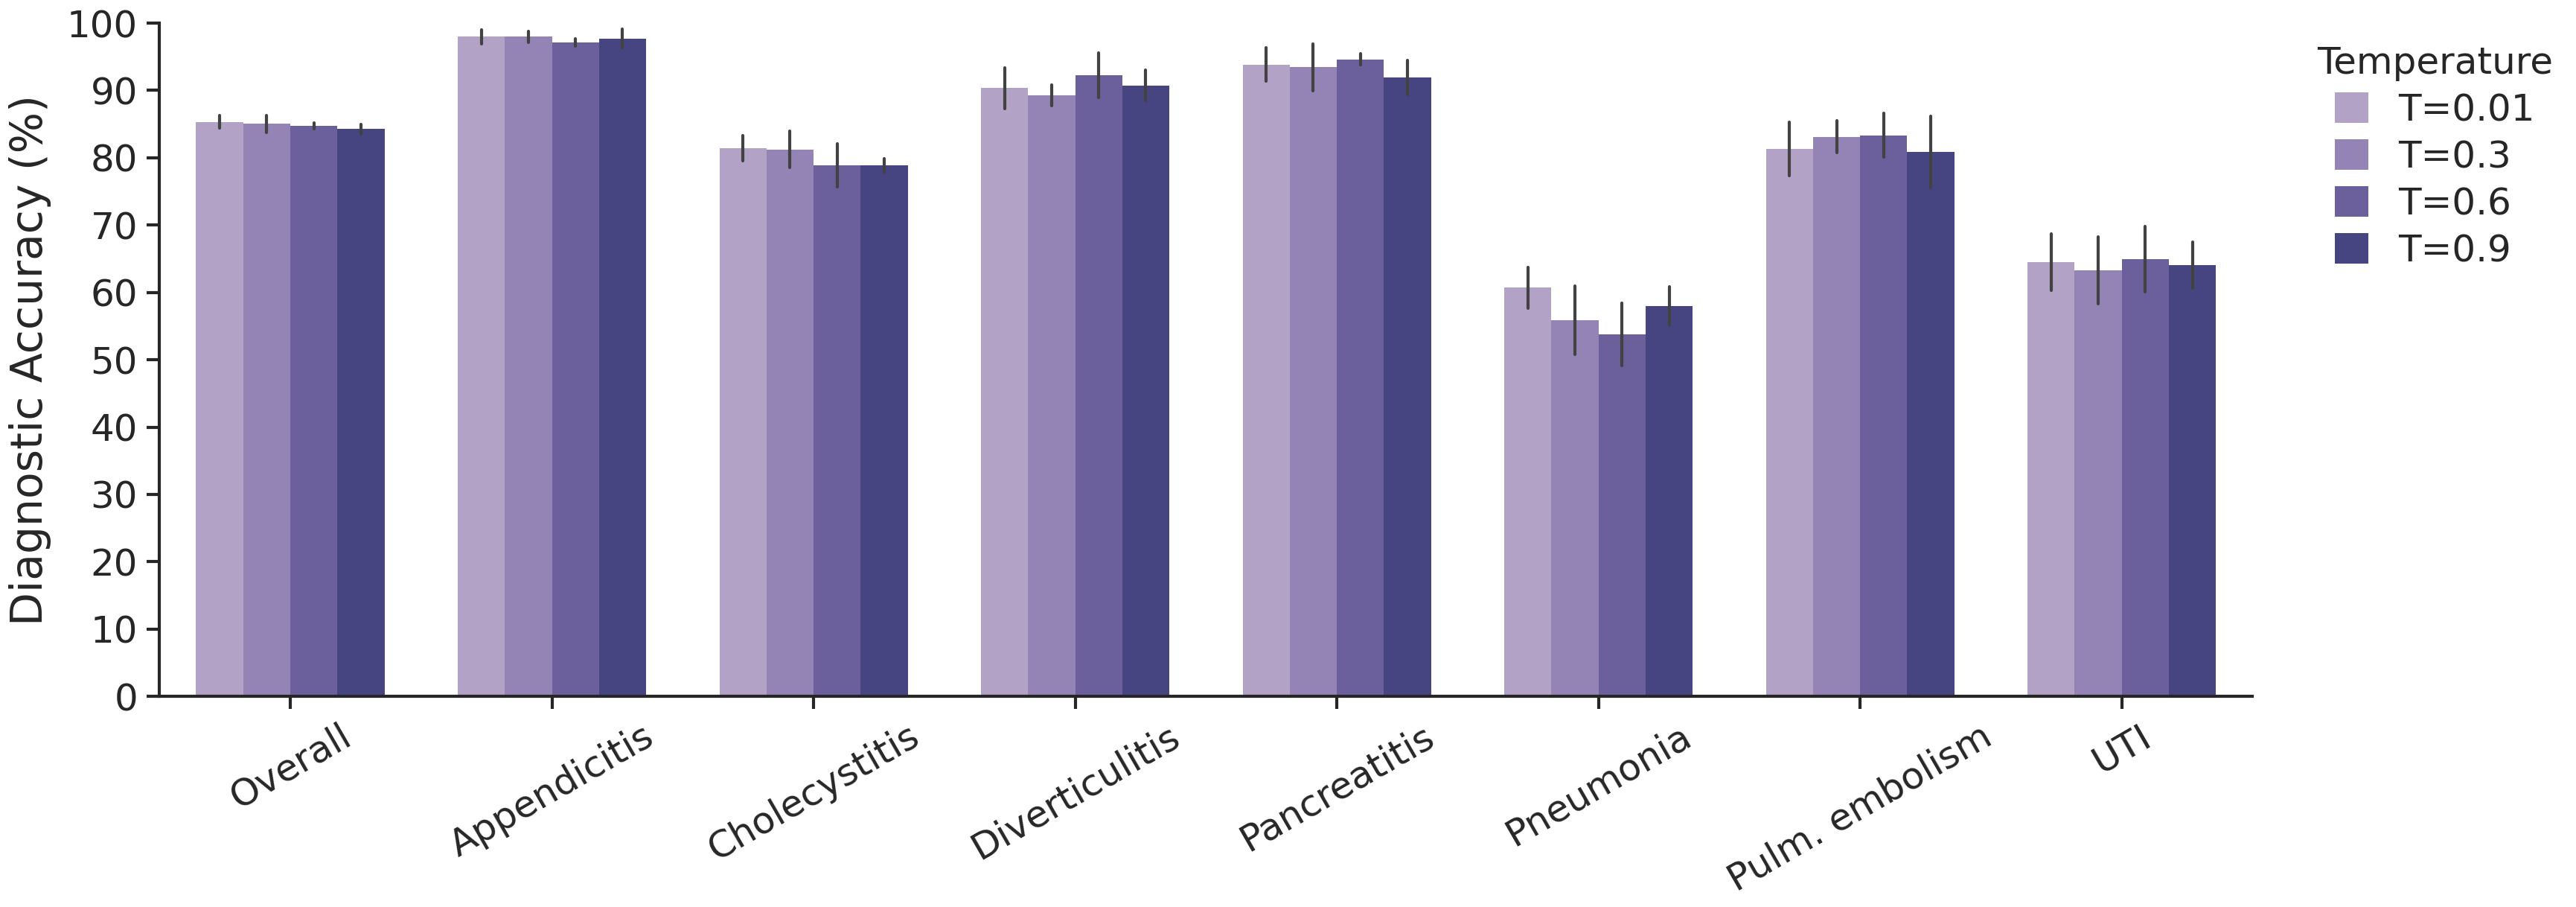

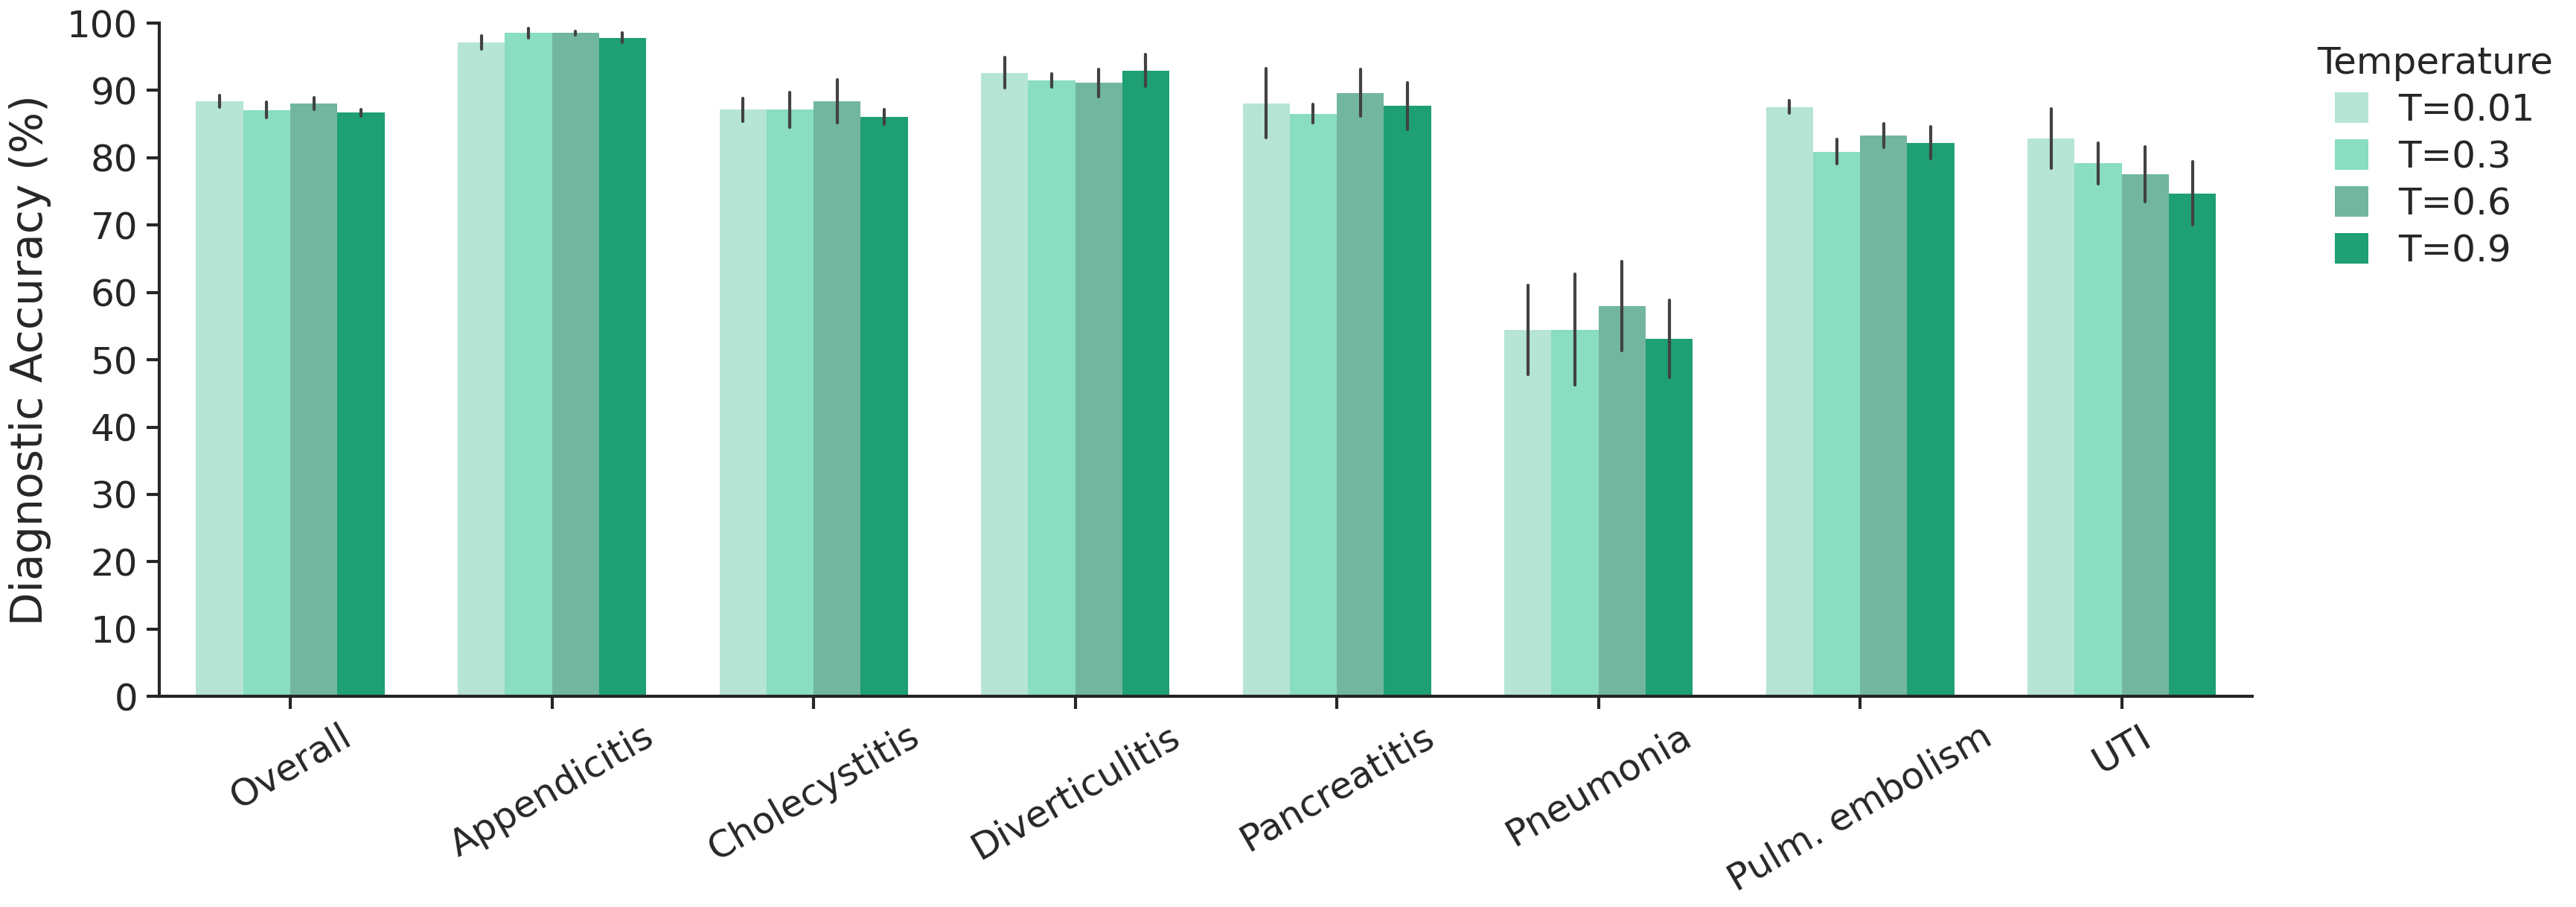

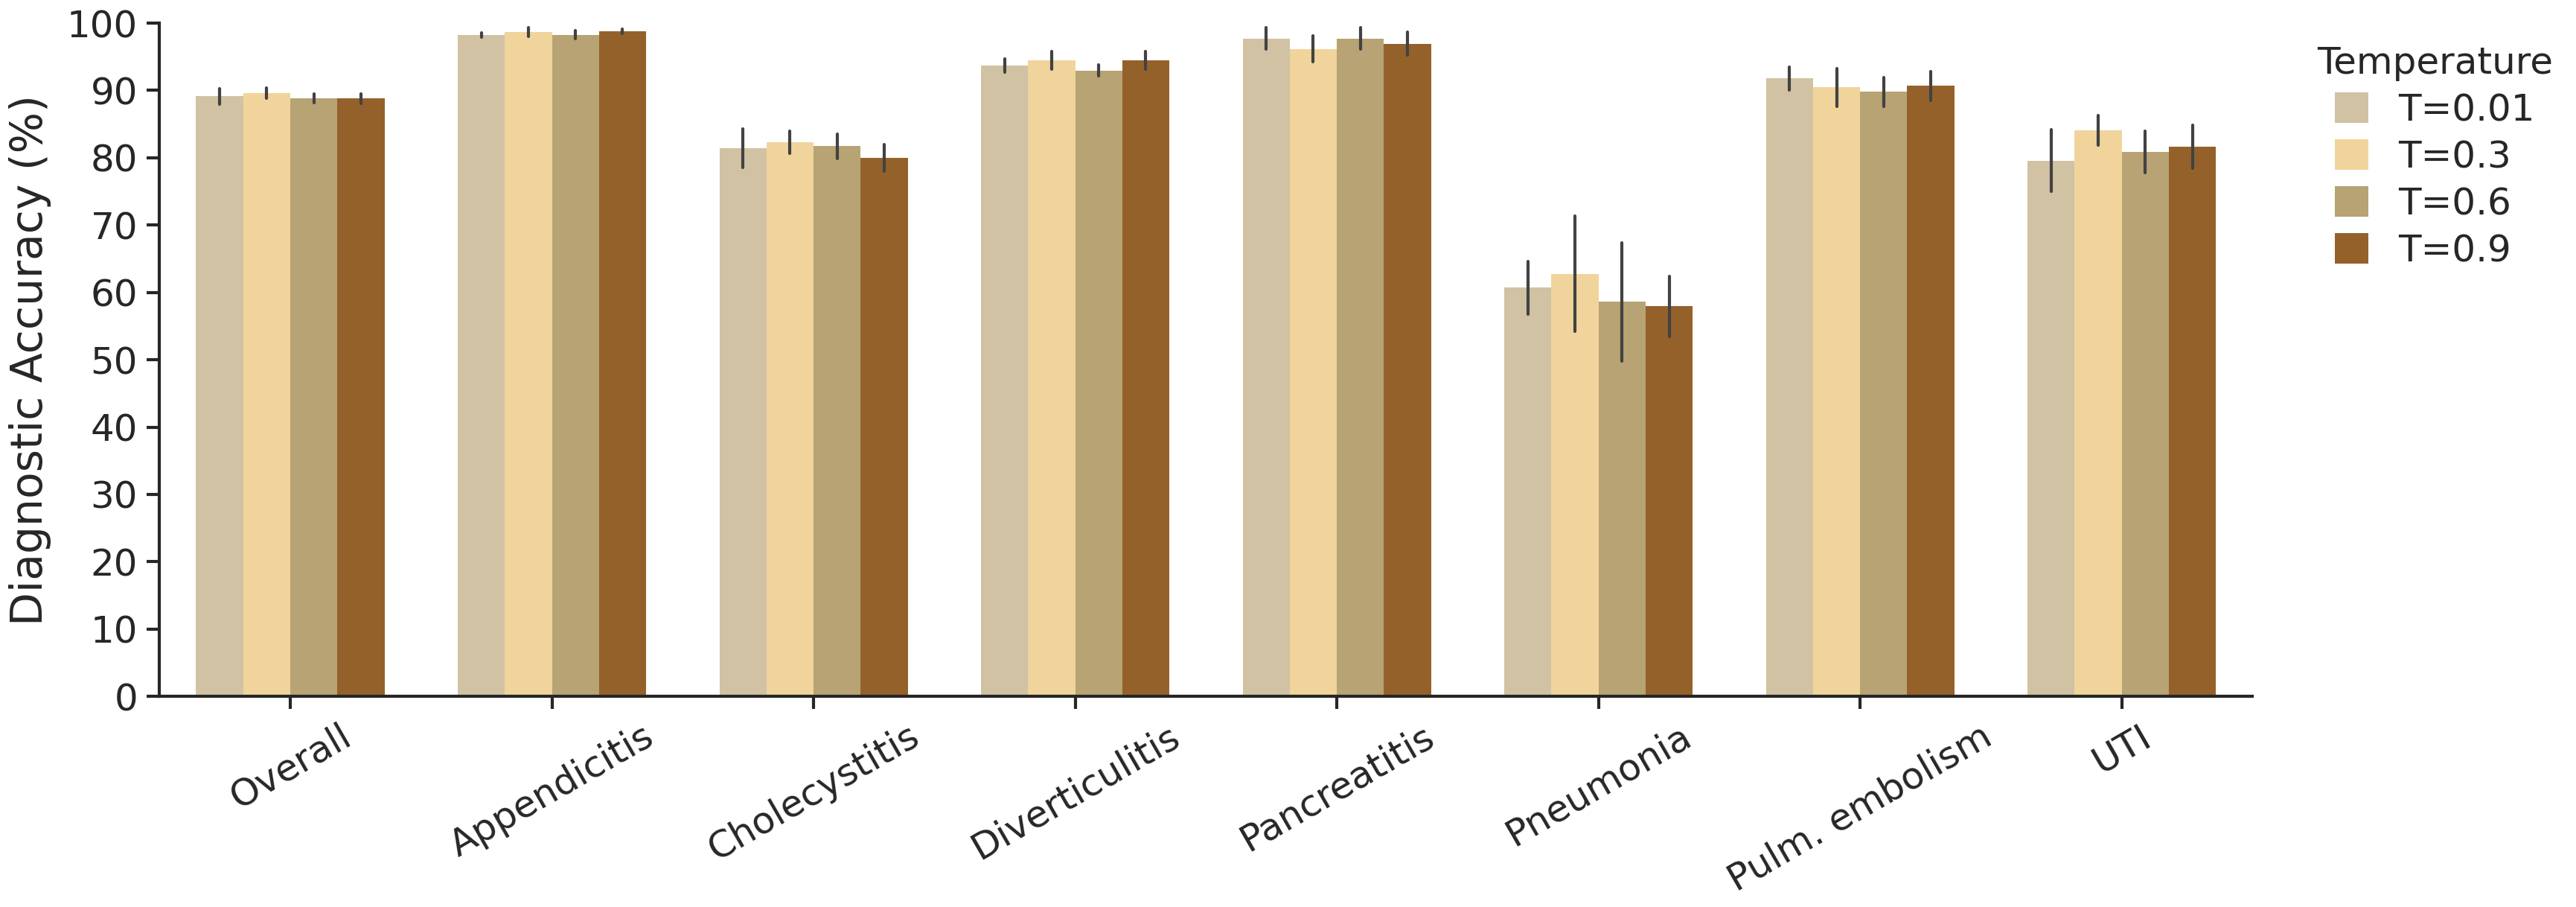

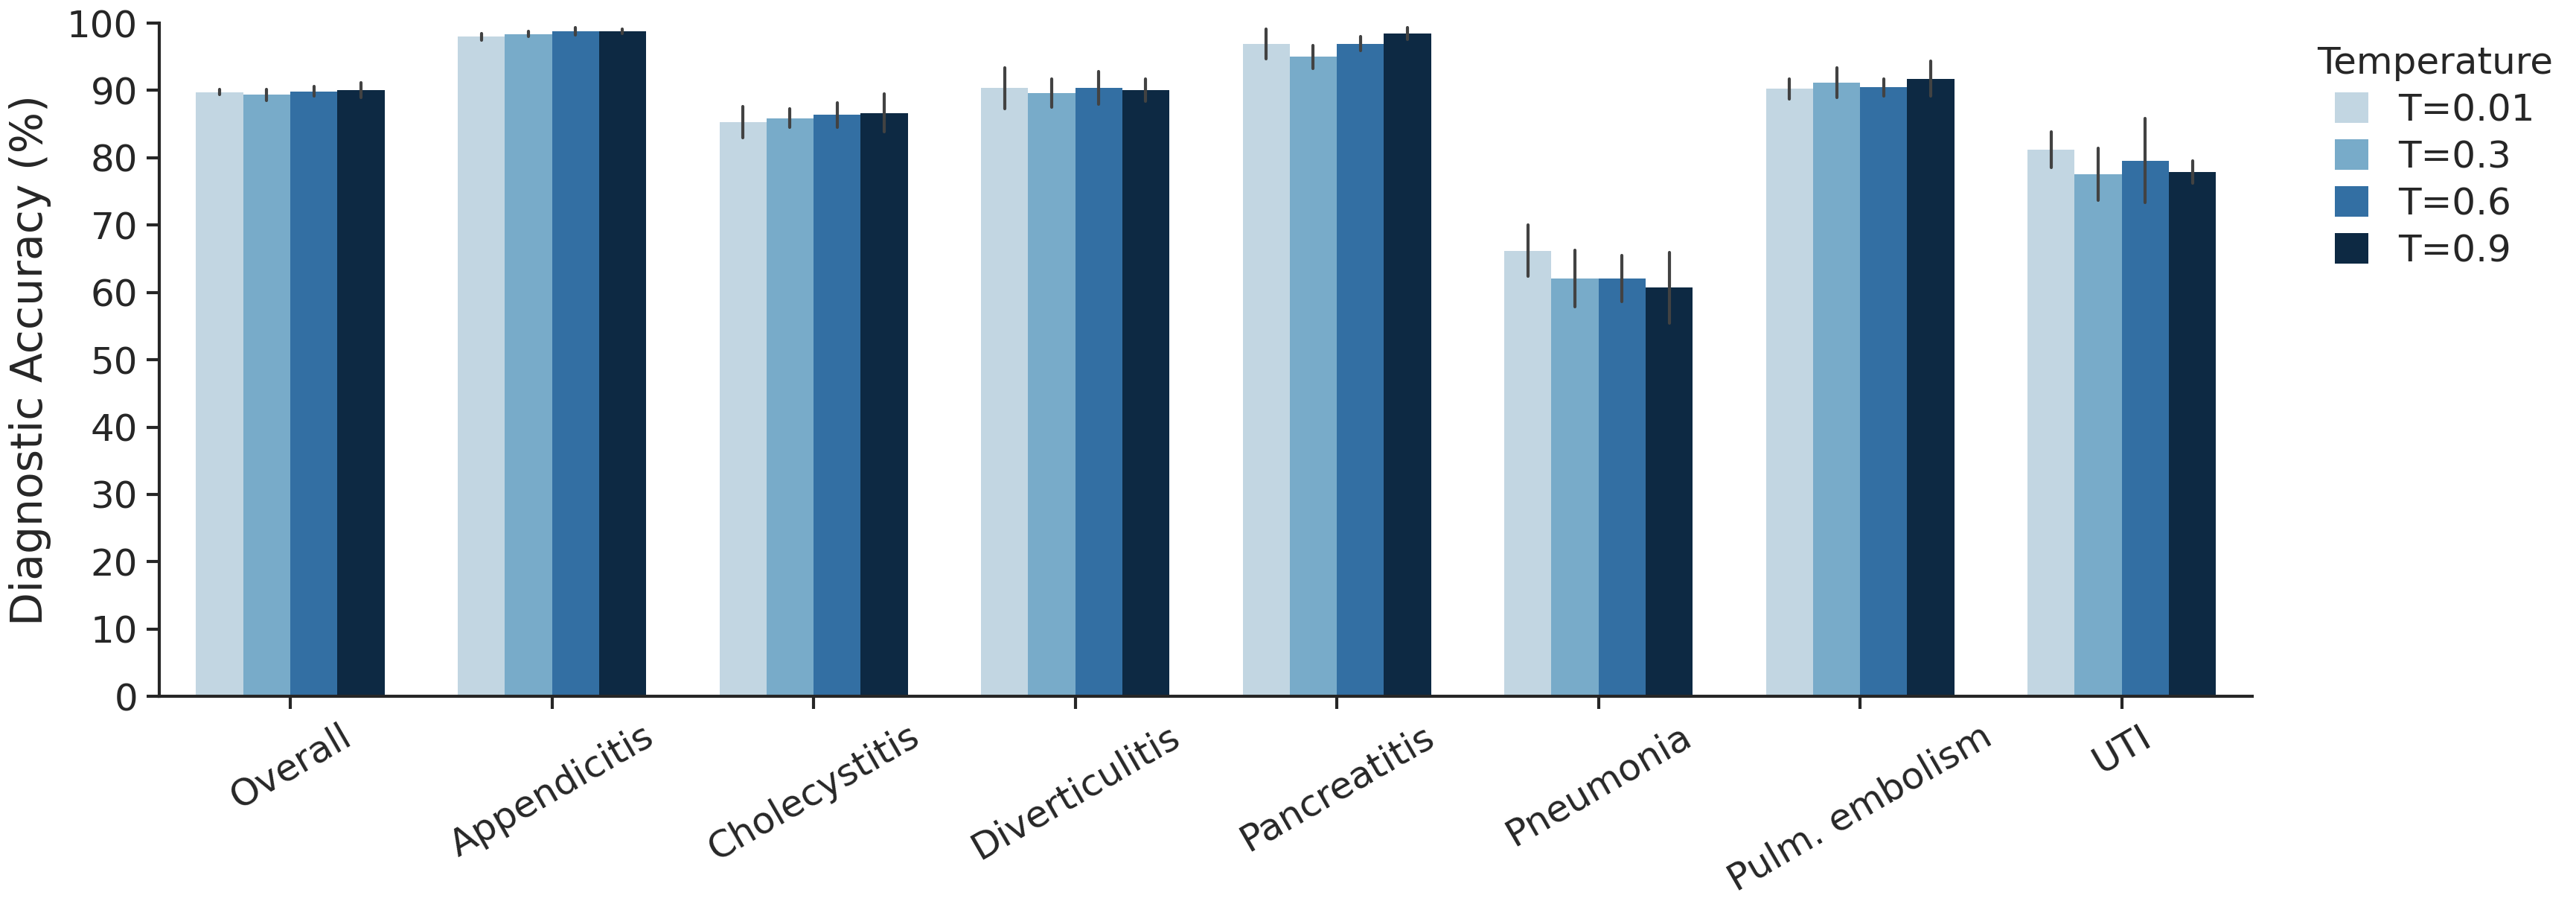

In [3]:
# cross temperatures
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
import seaborn as sns

# ========== 0) Style ==========
def setup_style(double_column: bool = True):
    if double_column:
        fig_w_in = 7.09
        fig_h_in = 2.2
    else:
        fig_w_in = 3.46
        fig_h_in = 2.0

    sns.set_theme(style="white", context="paper", font_scale=1.0)

    plt.rcParams.update({
        "figure.figsize": (fig_w_in, fig_h_in),
        "figure.dpi": 600,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,

        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "Liberation Sans"],
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype":'none',

        "font.size": 7,
        "axes.labelsize": 7,
        "axes.titlesize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "legend.fontsize": 6,
        "legend.title_fontsize": 6,

        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.width": 0.5,
        "ytick.major.width": 0.5,
        "xtick.minor.width": 0.4,
        "ytick.minor.width": 0.4,
        "xtick.major.size": 2.0,
        "ytick.major.size": 2.0,
        "xtick.minor.size": 1.5,
        "ytick.minor.size": 1.5,
        "axes.linewidth": 0.5,
        "patch.edgecolor": "none",
        "patch.linewidth": 0.0,

        "axes.grid": False,
        "figure.autolayout": False,
        "mathtext.default": "regular",
        "axes.titlepad": 3,
        "axes.labelpad": 2.5,
    })

setup_style(double_column=True)

# ========== 1) Constants and paths ==========
DATASET_NAME_MAP = {
    "appendicitis": "Appendicitis",
    "cholecystitis": "Cholecystitis",
    "diverticulitis": "Diverticulitis",
    "pancreatitis": "Pancreatitis",
    "pneumonia": "Pneumonia",
    "pulmonary_embolism": "Pulm. embolism",
    "uti": "UTI",
}
# DATASET_NAME_MAP = {
#     "vivabench_pubmed": "vivabench_pubmed",
# }
ALL_DATASETS = list(DATASET_NAME_MAP.keys())

GROUPS = [
    {
        "group_label": "GPT-OSS",
        "plots_base_dir": "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/aidoc_benchmark/Eval_10/GPT_OSS_120B",
        "models": [
            {
                "label": "T=0.01",
                "dir": "/mnt/bulk-uranus/lizhang/LiWorkSpace/data/evaluation/100/100.10",
                "color": "#B19CCB",
            },
            {
                "label": "T=0.3",
                "dir": "/mnt/bulk-uranus/lizhang/LiWorkSpace/data/evaluation/101/101.10",
                "color": "#917BBD",
            },
            {
                "label": "T=0.6",
                "dir": "/mnt/bulk-uranus/lizhang/LiWorkSpace/data/evaluation/99/99.10",
                "color": "#6656A6",
            },
            {
                "label": "T=0.9",
                "dir": "/mnt/bulk-uranus/lizhang/LiWorkSpace/data/evaluation/102/102.10",
                "color": "#3C3B8B",
            },
        ],
    },
    {
        "group_label": "GLM-4.5-Air",
        "plots_base_dir": "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/aidoc_benchmark/Eval_10/GLM_4.5_Air",
        "models": [
            {
                "label": "T=0.01",
                "dir": "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/63/5runs/63.10",
                "color": "#aeecd8",
            },
            {
                "label": "T=0.3",
                "dir": "/mnt/bulk-uranus/lizhang/LiWorkSpace/data/evaluation/105/105.10",
                "color": "#7bebc6",
            },
            {
                "label": "T=0.6",
                "dir": "/mnt/bulk-uranus/lizhang/LiWorkSpace/data/evaluation/106/106.10",
                "color": "#66c2a4",
            },
            {
                "label": "T=0.9",
                "dir": "/mnt/bulk-uranus/lizhang/LiWorkSpace/data/evaluation/107/107.10",
                "color": "#08b57b",
            },
        ],
    },
    {
        "group_label": "GLM-5",
        "plots_base_dir": "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/aidoc_benchmark/Eval_10/GLM_5",
        "models": [
            {
                "label": "T=0.01",
                "dir": "/mnt/bulk-uranus/lizhang/LiWorkSpace/data/evaluation/78/78.10",
                "color": "#d8c49d",
            },
            {
                "label": "T=0.3",
                "dir": "/mnt/bulk-uranus/lizhang/LiWorkSpace/data/evaluation/80/80.10",
                "color": "#fed98e",
            },
            {
                "label": "T=0.6",
                "dir": "/mnt/bulk-uranus/lizhang/LiWorkSpace/data/evaluation/79/79.10",
                "color": "#c2a768",
            },
            {
                "label": "T=0.9",
                "dir": "/mnt/bulk-uranus/lizhang/LiWorkSpace/data/evaluation/81/81.10",
                "color": "#a6611a",
            },
        ],
    },
    {
        "group_label": "Qwen-3.5",
        "plots_base_dir": "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/aidoc_benchmark/Eval_10/Qwen3.5",
        "models": [
            {
                "label": "T=0.01",
                "dir": "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/71/71.10",
                "color": "#bdd7e7",
            },
            {
                "label": "T=0.3",
                "dir": "/mnt/bulk-uranus/lizhang/LiWorkSpace/data/evaluation/83/83.10",
                "color": "#6baed6",
            },
            # # patient gpt-oss
            {
                "label": "T=0.6",
                "dir": "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/76/76.10",
                "color": "#2171b5",
            },
            {
                "label": "T=0.9",
                "dir": "/mnt/bulk-uranus/lizhang/LiWorkSpace/data/evaluation/82/82.10",
                "color": "#042a4c",
            },
        ],
    },


    # VivaBench
    # # {
    # #     "group_label": "GLM-4.5-Air",
    # #     "plots_base_dir": "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/vivabench_benchmark/confidence",
    # #     "models": [
    # #         {
    # #             "label": "T=0.6",
    # #             "dir": "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/97/97.10",
    # #             "color": "#66c2a4",
    # #         },
    # #     ],
    # # },
    # {
    #     "group_label": "GPT-OSS",
    #     "plots_base_dir": "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/vivabench_benchmark/confidence",
    #     "models": [
    #         {
    #             "label": "T=0.6",
    #             "dir": "/mnt/bulk-uranus/lizhang/LiWorkSpace/data/evaluation/103/103.10",
    #             "color": "#9294BB",
    #         },
    #     ],
    # },
    # {
    #     "group_label": "Qwen-3.5",
    #     "plots_base_dir": "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/vivabench_benchmark/confidence",
    #     "models": [
    #         {
    #             "label": "T=0.6",
    #             "dir": "/mnt/bulk-uranus/lizhang/LiWorkSpace/data/evaluation/84/84.10",
    #             "color": "#2c7bb6",
    #         },
    #     ],
    # },
]



# ========== 2) Load multiple runs for one model ==========
def load_model_runs(model_label, raw_dir):
    all_runs_data = []

    # Individual subdatasets
    for internal_name in ALL_DATASETS:
        agg_file_path = os.path.join(raw_dir, f"{internal_name}_multi_run.jsonl")
        if not os.path.exists(agg_file_path):
            print(f"  警告: 文件 {agg_file_path} 未找到，跳过 {internal_name}")
            continue

        df_agg = pd.read_json(agg_file_path, lines=True)
        if df_agg.empty or "runs" not in df_agg.columns:
            continue

        num_runs = len(df_agg["runs"].iloc[0])
        for i in range(num_runs):
            run_col = f"run_{i+1}_decision"
            df_agg[run_col] = df_agg["runs"].apply(
                lambda runs: runs[i]["decision"] if len(runs) > i else None
                # lambda runs: runs[i]["effective_decision"] if len(runs) > i else None
            )
            accuracy = df_agg[run_col].mean() * 100
            all_runs_data.append({
                "Dataset": DATASET_NAME_MAP[internal_name],
                "Accuracy": accuracy,
                "Run": i + 1,
                "Model": model_label,
            })

    # Overall
    all_agg_dfs = []
    for internal_name in ALL_DATASETS:
        fp = os.path.join(raw_dir, f"{internal_name}_multi_run.jsonl")
        if os.path.exists(fp):
            all_agg_dfs.append(pd.read_json(fp, lines=True))

    if all_agg_dfs:
        df_overall_agg = pd.concat(all_agg_dfs, ignore_index=True)
        num_runs_overall = len(df_overall_agg["runs"].iloc[0])

        for i in range(num_runs_overall):
            run_col = f"run_{i+1}_decision"
            df_overall_agg[run_col] = df_overall_agg["runs"].apply(
                lambda runs: runs[i]["decision"] if len(runs) > i else None
                # lambda runs: runs[i]["effective_decision"] if len(runs) > i else None
            )
            accuracy = df_overall_agg[run_col].mean() * 100
            all_runs_data.append({
                "Dataset": "Overall",
                "Accuracy": accuracy,
                "Run": i + 1,
                "Model": model_label,
            })

    return pd.DataFrame(all_runs_data)

# ========== 3) Aggregate multiple models ==========
for group_cfg in GROUPS:
    group_label = group_cfg["group_label"]
    plots_base_dir = group_cfg["plots_base_dir"]
    os.makedirs(plots_base_dir, exist_ok=True)
    models = group_cfg["models"]

    print(f"\n===== Processing group: {group_label} =====")
    ############T0.01 vs T0.3###################
    dir_t001 = next(m["dir"] for m in models if m["label"] == "T=0.01")
    dir_t03 = next(m["dir"] for m in models if m["label"] == "T=0.3")

    df_temp_test, df_temp_pairs = paired_temperature_comparison(
        dir_t001,
        dir_t03,
        label_a="T=0.01",
        label_b="T=0.3",
        decision_key="decision",
        n_boot=5000,
        random_state=42,
    )

    for col in ["Accuracy_diff_pp", "CI95_low_pp", "CI95_high_pp", "Permutation_p_one_sided", "Wilcoxon_p_one_sided"]:
        df_temp_test[col] = df_temp_test[col].round(4)

    temp_test_path = os.path.join(plots_base_dir, "temperature_T001_vs_T03_paired_test.csv")
    df_temp_test.to_csv(temp_test_path, index=False)

    print(df_temp_test)
    print(f"T=0.01 vs T=0.3 paired test saved to: {temp_test_path}")
    ###############################################

    all_model_dfs = []

    for model_cfg in models:
        print(f"正在加载 {model_cfg['label']} ...")
        df_model = load_model_runs(model_cfg["label"], model_cfg["dir"])
        if not df_model.empty:
            all_model_dfs.append(df_model)

    if not all_model_dfs:
        raise ValueError("没有成功加载任何 model 的结果，请检查路径。")

    df_combined = pd.concat(all_model_dfs, ignore_index=True)

    dataset_order = ["Overall"] + [name for name in DATASET_NAME_MAP.values()]
    df_combined["Dataset"] = df_combined["Dataset"].astype(str).str.strip()
    df_combined["Dataset"] = pd.Categorical(
        df_combined["Dataset"],
        categories=dataset_order,
        ordered=True
    )
    df_combined = df_combined.sort_values("Dataset")

    model_order = [m["label"] for m in models]

    df_combined["Model"] = pd.Categorical(
        df_combined["Model"],
        categories=model_order,
        ordered=True
    )

    # ========== Additional export: accuracy for each model (% +/- SD) ==========
    all_model_summary_dfs = []

    for model_cfg in models:
        print(f"正在计算 bootstrap CI for {model_cfg['label']} ...")
        df_model_summary = load_model_summary_with_case_bootstrap(
            model_cfg["label"],
            model_cfg["dir"]
        )
        if not df_model_summary.empty:
            all_model_summary_dfs.append(df_model_summary)

    if not all_model_summary_dfs:
        raise ValueError("没有成功生成任何 bootstrap summary，请检查路径。")

    df_summary_boot = pd.concat(all_model_summary_dfs, ignore_index=True)

    dataset_order = ["Overall"] + [name for name in DATASET_NAME_MAP.values()]
    model_order = [m["label"] for m in models]

    df_summary_boot["Dataset"] = pd.Categorical(
        df_summary_boot["Dataset"].astype(str).str.strip(),
        categories=dataset_order,
        ordered=True
    )

    df_summary_boot["Model"] = pd.Categorical(
        df_summary_boot["Model"],
        categories=model_order,
        ordered=True
    )

    df_summary_boot = df_summary_boot.sort_values(["Dataset", "Model"]).reset_index(drop=True)

    for col in ["Accuracy_mean", "Accuracy_sd", "CI95_low", "CI95_high"]:
        df_summary_boot[col] = df_summary_boot[col].round(2)

    # Create display columns: xx.xx +/- yy.yy
    df_summary_boot["Accuracy (% ± SD)"] = (
        df_summary_boot["Accuracy_mean"].map(lambda x: f"{x:.2f}")
        + " ± "
        + df_summary_boot["Accuracy_sd"].fillna(0).map(lambda x: f"{x:.2f}")
    )

    df_summary_boot["Accuracy (%; 95% CI)"] = (
        df_summary_boot["Accuracy_mean"].map(lambda x: f"{x:.2f}")
        + " ("
        + df_summary_boot["CI95_low"].map(lambda x: f"{x:.2f}")
        + "–"
        + df_summary_boot["CI95_high"].map(lambda x: f"{x:.2f}")
        + ")"
    )

    summary_boot_csv_path = os.path.join(plots_base_dir, "accuracy_summary_multi_T_bootstrap_CI.csv")
    df_summary_boot.to_csv(summary_boot_csv_path, index=False)

    print(f"case-level bootstrap CI 汇总已保存到: {summary_boot_csv_path}")
    # display(df_summary_boot)


    # ========== 4) Plot ==========
    fig, ax = plt.subplots()

    color_palette = {m["label"]: m["color"] for m in models}

    ax = sns.barplot(
        data=df_combined,
        x="Dataset",
        y="Accuracy",
        hue="Model",
        hue_order=model_order,
        palette=color_palette,
        errorbar="sd",
        capsize=0,
        err_kws={"linewidth": 0.5},
        width=0.72,
        linewidth=0,
        edgecolor="none",
        ax=ax,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_linewidth(0.5)

    ax.tick_params(
        axis="both",
        which="major",
        width=0.5,
        length=2.0,
        direction="out",
        top=False,
        right=False,
        bottom=True,
        left=True,
        pad=1.5,
    )

    ax.set_xlabel("")
    ax.set_ylabel("Diagnostic Accuracy (%)")

    ymin = max(0, df_combined["Accuracy"].min() - 5)
    ax.set_ylim(0, 100.0)
    ax.yaxis.set_major_locator(MultipleLocator(10))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))

    ax.tick_params(axis="x", labelrotation=30)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles=handles,
        labels=labels,
        title="Temperature",
        bbox_to_anchor=(1.02, 1.0),
        loc="upper left",
        frameon=False,
        handlelength=0.9,
        handleheight=0.9,
        borderaxespad=0.2,
        labelspacing=0.3,
        columnspacing=0.8,
    )

    plt.tight_layout(rect=[0, 0, 0.84, 1])

    # ========== 5) Save ==========
    os.makedirs(plots_base_dir, exist_ok=True)
    out_svg = os.path.join(plots_base_dir, "accuracy_comparison_multi_models.svg")
    out_png = os.path.join(plots_base_dir, "accuracy_comparison_multi_models.png")
    out_pdf = os.path.join(plots_base_dir, "accuracy_comparison_multi_models.pdf")

    plt.savefig(out_svg, format="svg", bbox_inches="tight")
    plt.savefig(out_png, format="png", bbox_inches="tight")
    plt.savefig(out_pdf, format="pdf", bbox_inches="tight")

    print(f"多模型分组条形图已保存到: {plots_base_dir}")
    # plt.show()
    # plt.close()


We compared T=0.01 and T=0.3 using a paired case-level analysis. For each case, correctness was averaged across repeated runs under each temperature, and the paired accuracy difference was estimated with case-level bootstrap 95% confidence intervals. A one-sided paired permutation test assessed whether T=0.01 outperformed T=0.3.


Loading Overall: Qwen-3.5 | T=0.6
Loading Overall: GPT-OSS | T=0.6


,Group,Temperature,Accuracy_mean,Accuracy_sd,n_runs
0,Qwen-3.5,T=0.6,72.222222,0.920246,5
1,GPT-OSS,T=0.6,67.959596,1.091190,5


Combined Overall bar plot saved to: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/aidoc_benchmark/Eval_10/ALL_MODELS


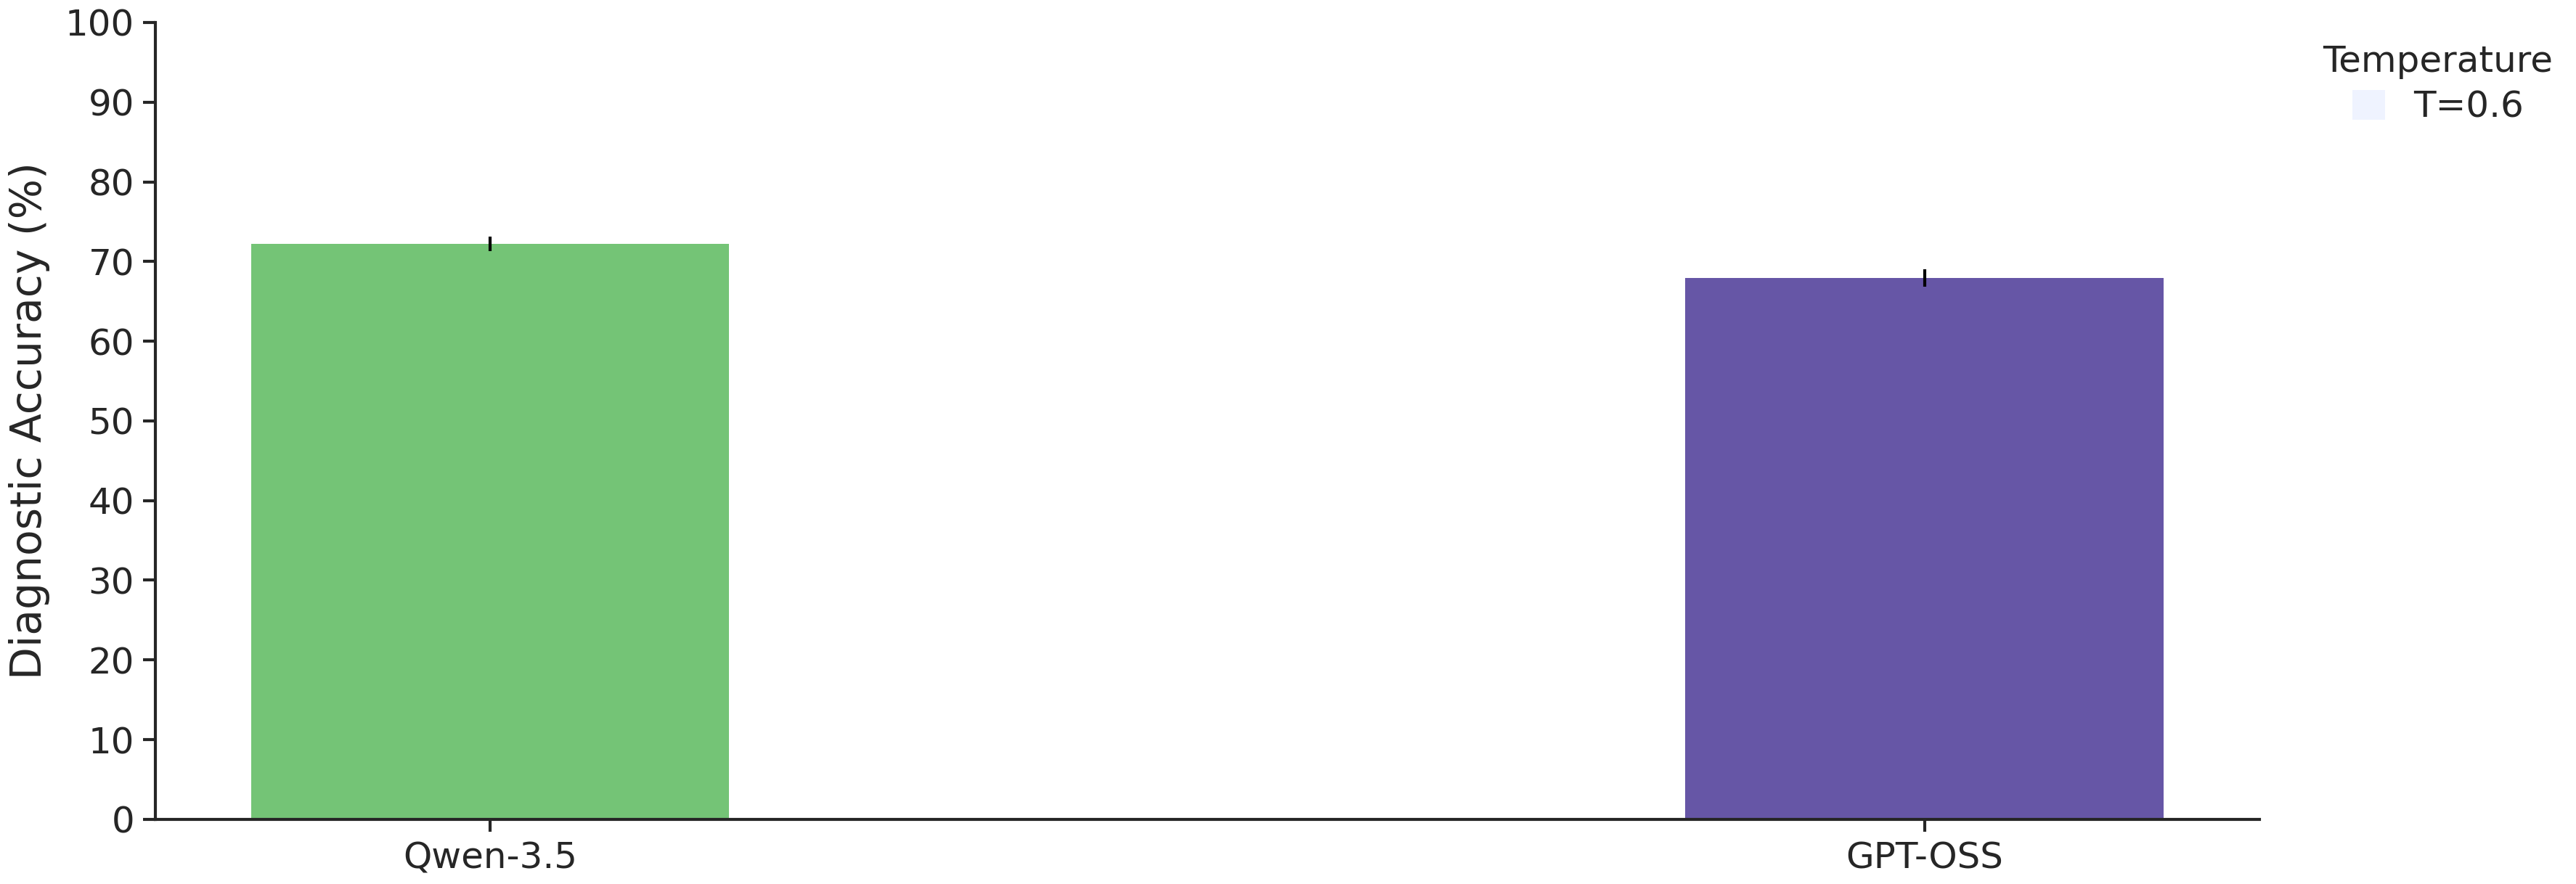

In [ ]:
# ========== Combined Overall accuracy: all models x temperatures ==========
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
import matplotlib.patches as mpatches

setup_style(double_column=True)

# 1) Load Overall only
overall_dfs = []

for group_cfg in GROUPS:
    group_label = group_cfg["group_label"]

    for model_cfg in group_cfg["models"]:
        print(f"Loading Overall: {group_label} | {model_cfg['label']}")

        df_model = load_model_runs(model_cfg["label"], model_cfg["dir"])
        if df_model.empty:
            continue

        df_overall = df_model[
            df_model["Dataset"].astype(str).str.strip().eq("Overall")
        ].copy()

        if df_overall.empty:
            continue

        df_overall["Group"] = group_label
        df_overall["Temperature"] = model_cfg["label"]
        overall_dfs.append(df_overall)

if not overall_dfs:
    raise ValueError("没有成功加载任何 Overall 结果，请检查 GROUPS 里的路径。")

df_overall_all = pd.concat(overall_dfs, ignore_index=True)

# 2) Mean / SD for error bars
df_plot = (
    df_overall_all
    .groupby(["Group", "Temperature"], observed=True)["Accuracy"]
    .agg(Accuracy_mean="mean", Accuracy_sd="std", n_runs="count")
    .reset_index()
)

group_order = [g["group_label"] for g in GROUPS]

temp_order = []
for g in GROUPS:
    for m in g["models"]:
        if m["label"] not in temp_order:
            temp_order.append(m["label"])

df_plot["Group"] = pd.Categorical(df_plot["Group"], categories=group_order, ordered=True)
df_plot["Temperature"] = pd.Categorical(df_plot["Temperature"], categories=temp_order, ordered=True)
df_plot = df_plot.sort_values(["Group", "Temperature"]).reset_index(drop=True)

display(df_plot)

# 3) Use original model_cfg colors, matching the previous cell's style
color_lookup = {
    (group_cfg["group_label"], model_cfg["label"]): model_cfg["color"]
    for group_cfg in GROUPS
    for model_cfg in group_cfg["models"]
}
# temp_palette = {
#     "T=0.01": "#eff3ff",
#     "T=0.3": "#bdd7e7",
#     "T=0.6": "#6baed6",
#     "T=0.9": "#2171b5",
# }

fig, ax = plt.subplots(figsize=(7.09, 2.2))

bar_width = 0.17
intra_gap = 0.0      # No spacing within groups.
group_gap = 0.34     # Leave a small gap between model groups.

x_cursor = 0.0
group_centers = []

for group in group_order:
    xs_this_group = []

    available_temps = [
        temp for temp in temp_order
        if not df_plot[
            (df_plot["Group"] == group) &
            (df_plot["Temperature"] == temp)
        ].empty
    ]

    for j, temp in enumerate(available_temps):
        row = df_plot[
            (df_plot["Group"] == group) &
            (df_plot["Temperature"] == temp)
        ]

        x = x_cursor + j * (bar_width + intra_gap)
        xs_this_group.append(x)

        mean_val = row["Accuracy_mean"].iloc[0]
        sd_val = row["Accuracy_sd"].iloc[0]

        ax.bar(
            x,
            mean_val,
            width=bar_width,
            color=color_lookup.get((group, temp), "#999999"),
            # color=temp_palette.get(temp, "#999999"),
            edgecolor="none",
            linewidth=0,
            yerr=sd_val,
            error_kw={
                "elinewidth": 0.5,
                "capsize": 0,
                "ecolor": "black",
            },
        )

    if xs_this_group:
        group_centers.append(np.mean(xs_this_group))

    x_cursor += len(available_temps) * bar_width + group_gap

# 4) 
ax.set_xticks(group_centers)
ax.set_xticklabels(group_order)
ax.set_xlabel("")
ax.set_ylabel("Diagnostic Accuracy (%)")

# ymin = max(0, (df_plot["Accuracy_mean"] - df_plot["Accuracy_sd"].fillna(0)).min() - 5)
ax.set_ylim(0, 100.0)
ax.yaxis.set_major_locator(MultipleLocator(10))
ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(0.5)

ax.grid(False)

ax.tick_params(
    axis="both",
    which="major",
    width=0.5,
    length=2.0,
    direction="out",
    top=False,
    right=False,
    bottom=True,
    left=True,
    pad=1.5,
)

# Legend shows temperature order, using neutral gray patches because colors are model-family-specific
legend_colors = ["#eff3ff", "#bdd7e7", "#6baed6", "#2171b5"]
legend_handles = [
    mpatches.Patch(color=legend_colors[i], label=temp)
    for i, temp in enumerate(temp_order)
]

ax.legend(
    handles=legend_handles,
    title="Temperature",
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
    frameon=False,
    handlelength=0.9,
    handleheight=0.9,
    borderaxespad=0.2,
    labelspacing=0.3,
    columnspacing=0.8,
)

plt.tight_layout(rect=[0, 0, 0.86, 1])

# 5) Save
combined_plot_dir = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/aidoc_benchmark/Eval_10/ALL_MODELS"
os.makedirs(combined_plot_dir, exist_ok=True)

out_svg = os.path.join(combined_plot_dir, "overall_accuracy_all_models_multi_T.svg")
out_png = os.path.join(combined_plot_dir, "overall_accuracy_all_models_multi_T.png")
out_pdf = os.path.join(combined_plot_dir, "overall_accuracy_all_models_multi_T.pdf")

plt.savefig(out_svg, format="svg", bbox_inches="tight")
plt.savefig(out_png, format="png", bbox_inches="tight")
plt.savefig(out_pdf, format="pdf", bbox_inches="tight")

print(f"Combined Overall bar plot saved to: {combined_plot_dir}")

plt.show()
plt.close()


In [4]:
def analyze_threshold_performance(
    df: pd.DataFrame, 
    score_column: str, 
    threshold: float,
    greater_is_better: bool = True
) -> dict:
    """
    分析在给定置信度分数和阈值下，筛选后数据的准确率和覆盖率。

    Args:
        df (pd.DataFrame): 包含所有数据的 Master DataFrame。
        score_column (str): 要用作筛选依据的置信度分数所在的列名
                            (e.g., 'Quantitative_Score', 'Semantic_Score').
        threshold (float): 用于筛选的置信度阈值。
        greater_is_better (bool): 分数的方向性。True表示分数越高越好，
                                  False表示分数越低越好。

    Returns:
        dict: 一个包含详细分析结果的字典。
    """
    
    # --- 1. Filter data by threshold ---
    if greater_is_better:
        filtered_df = df[df[score_column] >= threshold]
    else:
        # For metrics such as redundancy, where lower values are better
        filtered_df = df[df[score_column] <= threshold]

    # --- 2. Initialize result storage ---
    results = {
        'score_column': score_column,
        'threshold': threshold,
        'greater_is_better': greater_is_better,
        'by_dataset': {},
        'overall': {}
    }

    # --- 3. Calculate performance for each individual dataset ---
    # Get all dataset names present in the data
    datasets_in_df = df['dataset'].unique()
    
    for dataset in datasets_in_df:
        # Get this dataset from both the original and filtered DataFrames
        original_subset = df[df['dataset'] == dataset]
        filtered_subset = filtered_df[filtered_df['dataset'] == dataset]

        # Calculate the number and proportion of retained records (coverage)
        retained_count = len(filtered_subset)
        total_count = len(original_subset)
        coverage = retained_count / total_count if total_count > 0 else 0
        # coverage_ci_lower, coverage_ci_upper = compute_wilson_ci(retained_count, total_count)
        
        # Calculate accuracy after filtering.
        if retained_count > 0:
            accuracy = filtered_subset['final_decision'].mean()
            correct_retained_count = int(filtered_subset['final_decision'].sum())
            # accuracy_ci_lower, accuracy_ci_upper = compute_wilson_ci(correct_retained_count, retained_count)
        else:
            accuracy = np.nan
            correct_retained_count = 0
            # accuracy_ci_lower, accuracy_ci_upper = np.nan, np.nan


        results['by_dataset'][dataset] = {
            'accuracy': accuracy,
            # 'accuracy_ci_lower': accuracy_ci_lower,
            # 'accuracy_ci_upper': accuracy_ci_upper,
            'correct_retained_count': correct_retained_count,
            'retained_count': retained_count,
            'total_count': total_count,
            'coverage': coverage,
            # 'coverage_ci_lower': coverage_ci_lower,
            # 'coverage_ci_upper': coverage_ci_upper,
        }

        
    # --- 4. Calculate overall performance ---
    overall_total_count = len(df)
    overall_retained_count = len(filtered_df)
    overall_coverage = overall_retained_count / overall_total_count if overall_total_count > 0 else 0
    # overall_coverage_ci_lower, overall_coverage_ci_upper = compute_wilson_ci(
    #     overall_retained_count,
    #     overall_total_count
    # )
    
    if overall_retained_count > 0:
        overall_accuracy = filtered_df['final_decision'].mean()
        overall_correct_retained_count = int(filtered_df['final_decision'].sum())
        # overall_accuracy_ci_lower, overall_accuracy_ci_upper = compute_wilson_ci(
        #     overall_correct_retained_count,
        #     overall_retained_count
        # )
    else:
        overall_accuracy = np.nan
        overall_correct_retained_count = 0
        # overall_accuracy_ci_lower, overall_accuracy_ci_upper = np.nan, np.nan


    results['overall'] = {
        'accuracy': overall_accuracy,
        # 'accuracy_ci_lower': overall_accuracy_ci_lower,
        # 'accuracy_ci_upper': overall_accuracy_ci_upper,
        'correct_retained_count': overall_correct_retained_count,
        'retained_count': overall_retained_count,
        'total_count': overall_total_count,
        'coverage': overall_coverage,
        # 'coverage_ci_lower': overall_coverage_ci_lower,
        # 'coverage_ci_upper': overall_coverage_ci_upper,
    }
    
    return results


# Add parameters before the combined-plot cell
score_column = "Consistency_Dx"
threshold = 0.9
greater_is_better = True

In [5]:
# Step 3：Build the summary DataFrame shared by Panels A and B

summary_rows = []

for group_cfg in GROUPS:
    group_label = group_cfg["group_label"]

    for model_cfg in group_cfg["models"]:
        temp_label = model_cfg["label"]
        color = model_cfg["color"]

        # ---------- full coverage accuracy ----------
        df_model = load_model_runs(temp_label, model_cfg["dir"])
        df_overall = df_model[
            df_model["Dataset"].astype(str).str.strip().eq("Overall")
        ].copy()

        if df_overall.empty:
            continue

        full_accuracy_mean = df_overall["Accuracy"].mean()
        full_accuracy_sd = df_overall["Accuracy"].std()

        # ---------- threshold-filtered accuracy / coverage ----------
        csv_path = os.path.join(model_cfg["dir"], "master_feature_dataframe.csv")

        if not os.path.exists(csv_path):
            print(f"Missing csv: {group_label} | {temp_label} | {csv_path}")
            filtered_accuracy = np.nan
            coverage = np.nan
            retained_count = np.nan
            total_count = np.nan
        else:
            df_feat = pd.read_csv(csv_path)


            res = analyze_threshold_performance(
                df=df_feat,
                score_column=score_column,
                threshold=threshold,
                greater_is_better=greater_is_better,
            )

            filtered_accuracy = res["overall"]["accuracy"] * 100
            coverage = res["overall"]["coverage"] * 100
            retained_count = res["overall"]["retained_count"]
            total_count = res["overall"]["total_count"]

        summary_rows.append({
            "Group": group_label,
            "Temperature": temp_label,
            "Color": color,
            "Full_accuracy_mean": full_accuracy_mean,
            "Full_accuracy_sd": full_accuracy_sd,
            "Filtered_accuracy": filtered_accuracy,
            "Coverage": coverage,
            "Retained_count": retained_count,
            "Total_count": total_count,
        })

df_selective = pd.DataFrame(summary_rows)

group_order = [g["group_label"] for g in GROUPS]
temp_order = []
for g in GROUPS:
    for m in g["models"]:
        if m["label"] not in temp_order:
            temp_order.append(m["label"])

df_selective["Group"] = pd.Categorical(
    df_selective["Group"],
    categories=group_order,
    ordered=True,
)
df_selective["Temperature"] = pd.Categorical(
    df_selective["Temperature"],
    categories=temp_order,
    ordered=True,
)

df_selective = df_selective.sort_values(["Group", "Temperature"]).reset_index(drop=True)

display(df_selective)



,Group,Temperature,Color,Full_accuracy_mean,Full_accuracy_sd,Filtered_accuracy,Coverage,Retained_count,Total_count
0,GPT-OSS,T=0.01,#B19CCB,85.299456,0.943040,97.202797,51.905626,286,551
1,GPT-OSS,T=0.3,#917BBD,85.045372,1.274301,97.744361,48.275862,266,551
2,GPT-OSS,T=0.6,#6656A6,84.754991,0.425628,97.923875,52.450091,289,551
3,GPT-OSS,T=0.9,#3C3B8B,84.246824,0.752684,98.148148,49.001815,270,551
4,GLM-4.5-Air,T=0.01,#aeecd8,88.421053,0.874163,98.897059,49.364791,272,551
5,GLM-4.5-Air,T=0.3,#7bebc6,87.114338,1.140636,99.250936,48.457350,267,551
6,GLM-4.5-Air,T=0.6,#66c2a4,88.094374,0.894647,99.190283,44.827586,247,551
7,GLM-4.5-Air,T=0.9,#08b57b,86.678766,0.473263,98.654709,40.471869,223,551
8,GLM-5,T=0.01,#d8c49d,89.110708,1.126105,97.178683,57.894737,319,551
9,GLM-5,T=0.3,#fed98e,89.651675,0.776573,98.095238,57.168784,315,551


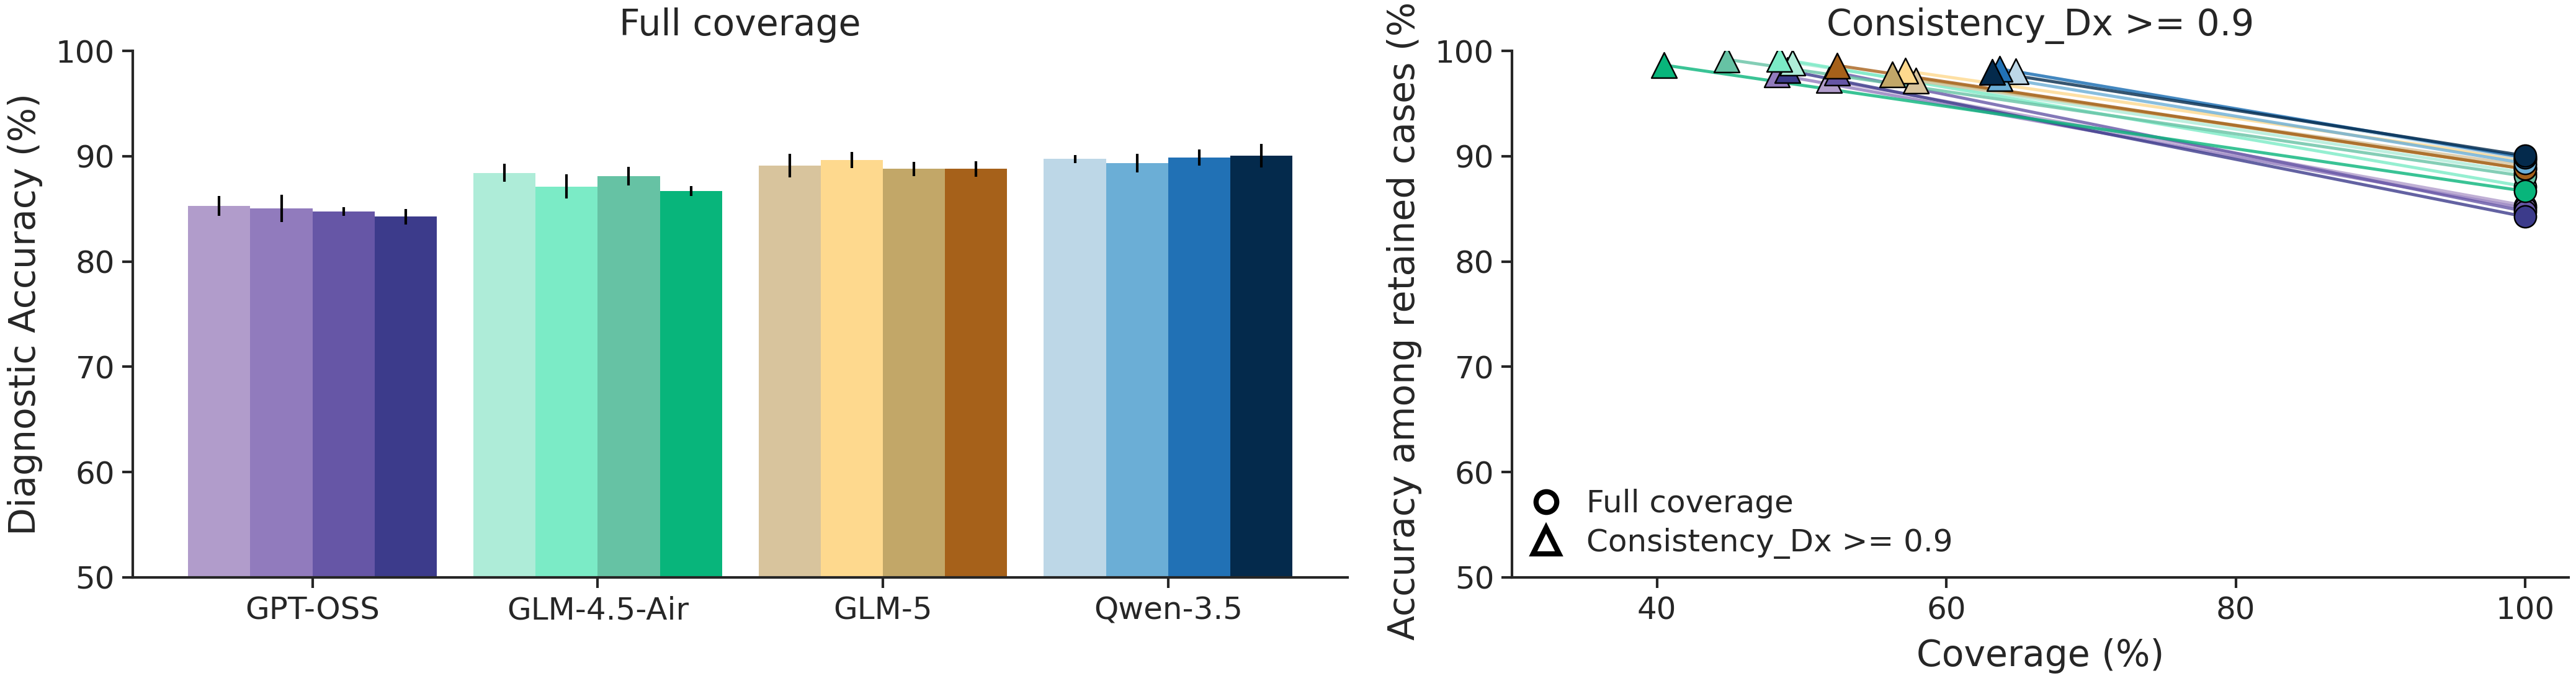

In [6]:
''''
Step 4：画 Panel A + Panel B

这里 Panel A 是原始 Overall accuracy bar plot；Panel B 是 circle/full coverage 和 triangle/filtered operating point。
'''
import matplotlib.patches as mpatches


fig, axes = plt.subplots(
    1, 2,
    figsize=(7.09, 2),
    gridspec_kw={"width_ratios": [1.15, 1.0]}
)

ax_a, ax_b = axes

# ===================== Panel A: Full coverage bar plot =====================
bar_width = 0.17
group_gap = 0.1 #0.34
x_cursor = 0.0
group_centers = []

for group in group_order:
    xs_this_group = []

    df_g = df_selective[df_selective["Group"] == group]

    for j, (_, row) in enumerate(df_g.iterrows()):
        x = x_cursor + j * bar_width
        xs_this_group.append(x)

        ax_a.bar(
            x,
            row["Full_accuracy_mean"],
            width=bar_width,
            color=row["Color"],
            edgecolor="none",
            linewidth=0,
            yerr=row["Full_accuracy_sd"],
            error_kw={
                "elinewidth": 0.5,
                "capsize": 0,
                "ecolor": "black",
            },
        )

    if xs_this_group:
        group_centers.append(np.mean(xs_this_group))

    x_cursor += len(df_g) * bar_width + group_gap

temp_legend_colors = ["#eeeeee", "#bbbbbb", "#777777", "#525252"]

temp_handles = [
    mpatches.Patch(color=temp_legend_colors[i], label=temp)
    for i, temp in enumerate(temp_order)
]

# ax_a.legend(
#     handles=temp_handles,
#     title="Temperature",
#     frameon=False,
#     loc="upper left",
#     bbox_to_anchor=(0.02, 1.05),
#     handlelength=0.9,
#     handleheight=0.9,
#     borderaxespad=0.2,
#     labelspacing=0.3,
# )

ax_a.set_xticks(group_centers)
ax_a.set_xticklabels(group_order, rotation=0)
ax_a.set_xlabel("")
ax_a.set_ylabel("Diagnostic Accuracy (%)")
ax_a.set_ylim(50, 100)
ax_a.yaxis.set_major_locator(MultipleLocator(10))
ax_a.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
ax_a.set_title("Full coverage")


# ===================== Panel B: Selective prediction =====================
for _, row in df_selective.iterrows():
    color = row["Color"]

    full_x = 100.0
    full_y = row["Full_accuracy_mean"]

    filtered_x = row["Coverage"]
    filtered_y = row["Filtered_accuracy"]

    if pd.isna(filtered_x) or pd.isna(filtered_y):
        continue

    # connection line
    ax_b.plot(
        [full_x, filtered_x],
        [full_y, filtered_y],
        color=color,
        linewidth=0.6,
        alpha=0.8,
        zorder=1,
    )

    # full coverage baseline
    ax_b.scatter(
        full_x,
        full_y,
        marker="o",
        s=18,
        color=color,
        edgecolor="black",
        linewidth=0.3,
        zorder=3,
    )

    # threshold-filtered point
    ax_b.scatter(
        filtered_x,
        filtered_y,
        marker="^",
        s=24,
        color=color,
        edgecolor="black",
        linewidth=0.3,
        zorder=4,
    )

ax_b.set_xlabel("Coverage (%)")
ax_b.set_ylabel("Accuracy among retained cases (%)")
ax_b.set_xlim(30, 103)
ax_b.set_ylim(50, 100)
ax_b.xaxis.set_major_locator(MultipleLocator(20))
ax_b.yaxis.set_major_locator(MultipleLocator(10))
ax_b.xaxis.set_major_formatter(FormatStrFormatter("%.0f"))
ax_b.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
ax_b.set_title(f"{score_column} >= {threshold}")


# ===================== Shared styling =====================
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_linewidth(0.5)

    ax.grid(False)
    ax.tick_params(
        axis="both",
        which="major",
        width=0.5,
        length=2.0,
        direction="out",
        top=False,
        right=False,
        bottom=True,
        left=True,
        pad=1.5,
    )

# marker legend for Panel B
marker_handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=4,
        label="Full coverage",
    ),
    plt.Line2D(
        [0], [0],
        marker="^",
        color="none",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=5,
        label=f"{score_column} >= {threshold}",
    ),
]

ax_b.legend(
    handles=marker_handles,
    frameon=False,
    loc="lower left",
    handlelength=1.0,
    borderaxespad=0.2,
    labelspacing=0.3,
)

plt.tight_layout()

combined_plot_dir = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/aidoc_benchmark/Eval_10"
os.makedirs(combined_plot_dir, exist_ok=True)

out_svg = os.path.join(combined_plot_dir, "overall_accuracy_selective_prediction.svg")
out_png = os.path.join(combined_plot_dir, "overall_accuracy_selective_prediction.png")
out_pdf = os.path.join(combined_plot_dir, "overall_accuracy_selective_prediction.pdf")

plt.savefig(out_svg, format="svg", bbox_inches="tight")
plt.savefig(out_png, format="png", bbox_inches="tight")
plt.savefig(out_pdf, format="pdf", bbox_inches="tight")

plt.show()
plt.close()


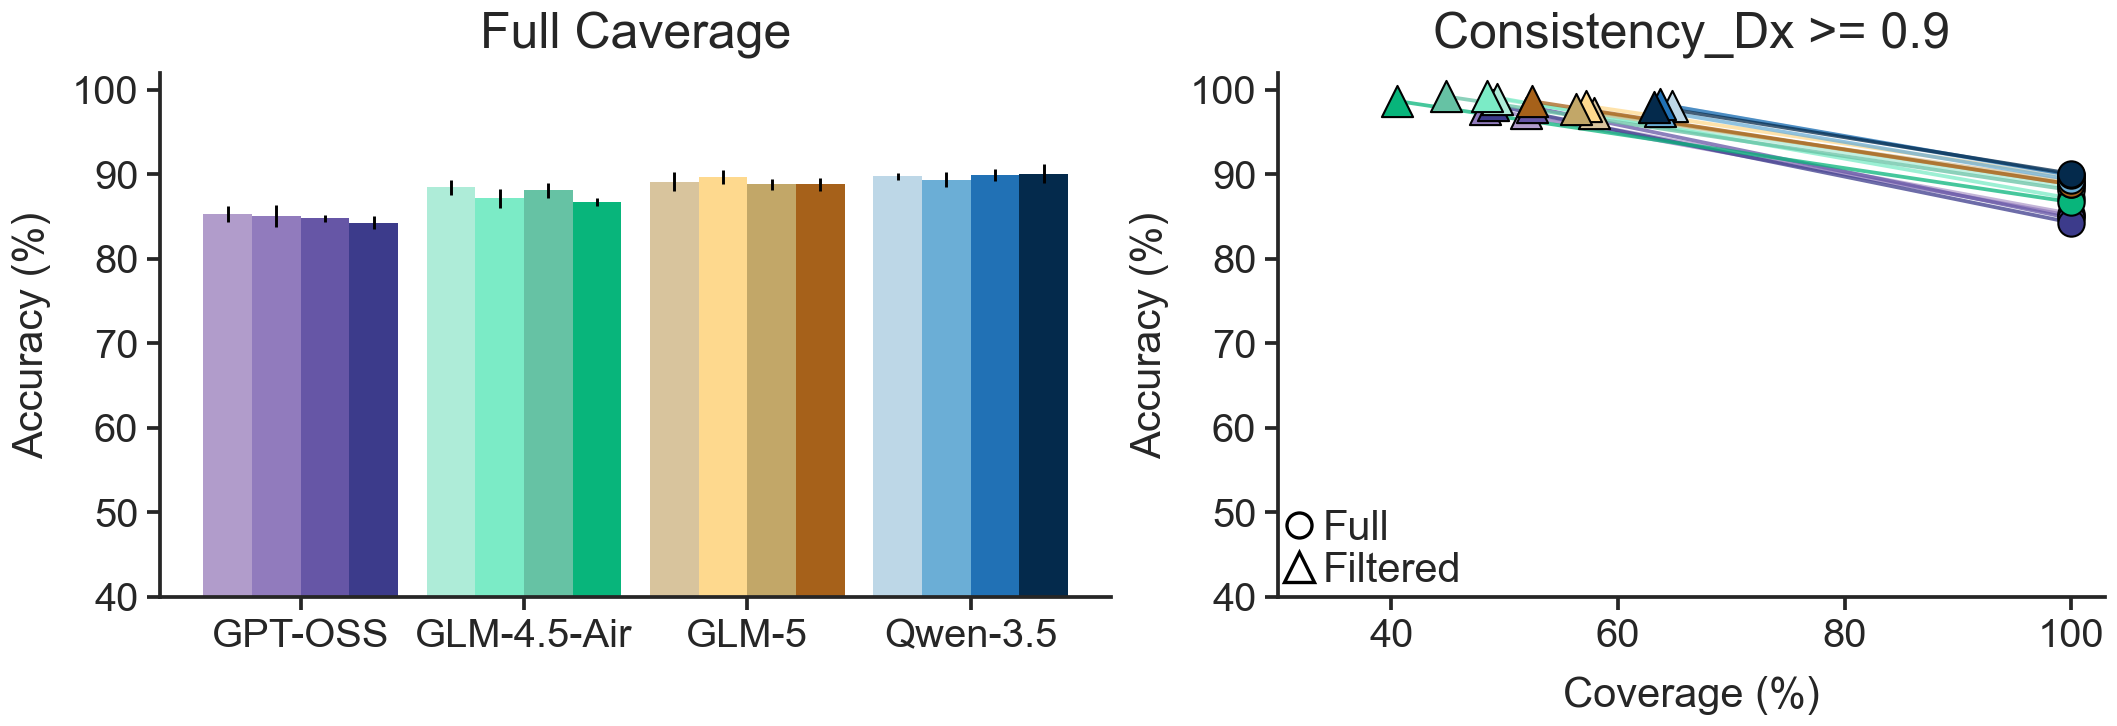

Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/aidoc_benchmark/Eval_10/overall_accuracy_selective_prediction.svg
Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/aidoc_benchmark/Eval_10/overall_accuracy_selective_prediction.png
Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/aidoc_benchmark/Eval_10/overall_accuracy_selective_prediction.pdf


In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

# =====================
# Style
# =====================
try:
    arial_path = "/usr/share/fonts/truetype/msttcorefonts/Arial.ttf"
    fm.fontManager.addfont(arial_path)
    plt.rcParams["font.family"] = "Arial"
except FileNotFoundError:
    plt.rcParams["font.family"] = "sans-serif"

plt.rcParams.update({
    "font.size": 5,
    "axes.labelsize": 5,
    "axes.titlesize": 6,
    "xtick.labelsize": 4.8,
    "ytick.labelsize": 4.8,
    "legend.fontsize": 5,
    "axes.linewidth": 0.45,
    "xtick.major.width": 0.45,
    "ytick.major.width": 0.45,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype":'none',
})

# =====================
# Figure
# =====================
fig, axes = plt.subplots(
    1, 2,
    figsize=(7.09 / 2, 1.22),  # ~90 mm x 30 mm
    gridspec_kw={"width_ratios": [1.15, 1.0]}
)

ax_a, ax_b = axes

# ===================== Panel A: Full coverage bar plot =====================
bar_width = 0.17
group_gap = 0.10
x_cursor = 0.0
group_centers = []

for group in group_order:
    xs_this_group = []
    df_g = df_selective[df_selective["Group"] == group]

    for j, (_, row) in enumerate(df_g.iterrows()):
        x = x_cursor + j * bar_width
        xs_this_group.append(x)

        ax_a.bar(
            x,
            row["Full_accuracy_mean"],
            width=bar_width,
            color=row["Color"],
            edgecolor="none",
            linewidth=0,
            yerr=row["Full_accuracy_sd"],
            error_kw={
                "elinewidth": 0.35,
                "capsize": 0,
                "ecolor": "black",
            },
        )

    if xs_this_group:
        group_centers.append(np.mean(xs_this_group))

    x_cursor += len(df_g) * bar_width + group_gap

ax_a.set_xticks(group_centers)
ax_a.set_xticklabels(group_order, rotation=0)
ax_a.set_xlabel("")
ax_a.set_ylabel("Accuracy (%)")
ax_a.set_ylim(40, 102)
ax_a.yaxis.set_major_locator(MultipleLocator(10))
ax_a.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
ax_a.set_title("Full Caverage")

# ===================== Panel B: Selective prediction =====================
for _, row in df_selective.iterrows():
    color = row["Color"]

    full_x = 100.0
    full_y = row["Full_accuracy_mean"]

    filtered_x = row["Coverage"]
    filtered_y = row["Filtered_accuracy"]

    if pd.isna(filtered_x) or pd.isna(filtered_y):
        continue

    ax_b.plot(
        [full_x, filtered_x],
        [full_y, filtered_y],
        color=color,
        linewidth=0.45,
        alpha=0.75,
        zorder=1,
    )

    ax_b.scatter(
        full_x,
        full_y,
        marker="o",
        s=10,
        color=color,
        edgecolor="black",
        linewidth=0.25,
        zorder=3,
    )

    ax_b.scatter(
        filtered_x,
        filtered_y,
        marker="^",
        s=14,
        color=color,
        edgecolor="black",
        linewidth=0.25,
        zorder=4,
    )

ax_b.set_xlabel("Coverage (%)")
ax_b.set_ylabel("Accuracy (%)")
ax_b.set_xlim(30, 103)
ax_b.set_ylim(40, 102)
ax_b.xaxis.set_major_locator(MultipleLocator(20))
ax_b.yaxis.set_major_locator(MultipleLocator(10))
ax_b.xaxis.set_major_formatter(FormatStrFormatter("%.0f"))
ax_b.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
ax_b.set_title(f"{score_column} >= {threshold}")

# ===================== Shared styling =====================
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for spine in ["left", "bottom"]:
        ax.spines[spine].set_linewidth(0.45)

    ax.grid(False)
    ax.tick_params(
        axis="both",
        which="major",
        width=0.45,
        length=1.6,
        direction="out",
        top=False,
        right=False,
        bottom=True,
        left=True,
        pad=1.0,
    )

# ===================== Compact marker legend for Panel B =====================
marker_handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=0.4,
        markersize=3,
        label="Full",
    ),
    plt.Line2D(
        [0], [0],
        marker="^",
        color="none",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=0.4,
        markersize=3.5,
        label="Filtered",
    ),
]

ax_b.legend(
    handles=marker_handles,
    frameon=False,
    facecolor="none",
    loc="lower left",
    handlelength=0.65,
    handletextpad=0.25,
    borderaxespad=0.12,
    borderpad=0.05,
    labelspacing=0.10,
    fontsize=5,
)

plt.tight_layout(pad=0.35, w_pad=0.45)

# =====================
# Save
# =====================
combined_plot_dir = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/aidoc_benchmark/Eval_10"
os.makedirs(combined_plot_dir, exist_ok=True)

out_svg = os.path.join(combined_plot_dir, "overall_accuracy_selective_prediction.svg")
out_png = os.path.join(combined_plot_dir, "overall_accuracy_selective_prediction.png")
out_pdf = os.path.join(combined_plot_dir, "overall_accuracy_selective_prediction.pdf")

plt.savefig(out_svg, format="svg", bbox_inches="tight")
plt.savefig(out_png, format="png", bbox_inches="tight", dpi=600)
plt.savefig(out_pdf, format="pdf", bbox_inches="tight")

plt.show()
plt.close()

print(f"Saved: {out_svg}")
print(f"Saved: {out_png}")
print(f"Saved: {out_pdf}")


--- Loading and Processing Data for Critic Ablation Study ---


/tmp/ipykernel_433140/4203569333.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_combined.groupby(['Dataset', 'Model'])['Accuracy'].mean().unstack()


summary saved to: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/56/56.10/accuracy_ablation_critic_agent_summary.csv
消融研究对比图已保存到: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/56/56.10/accuracy_ablation_critic_agent.svg


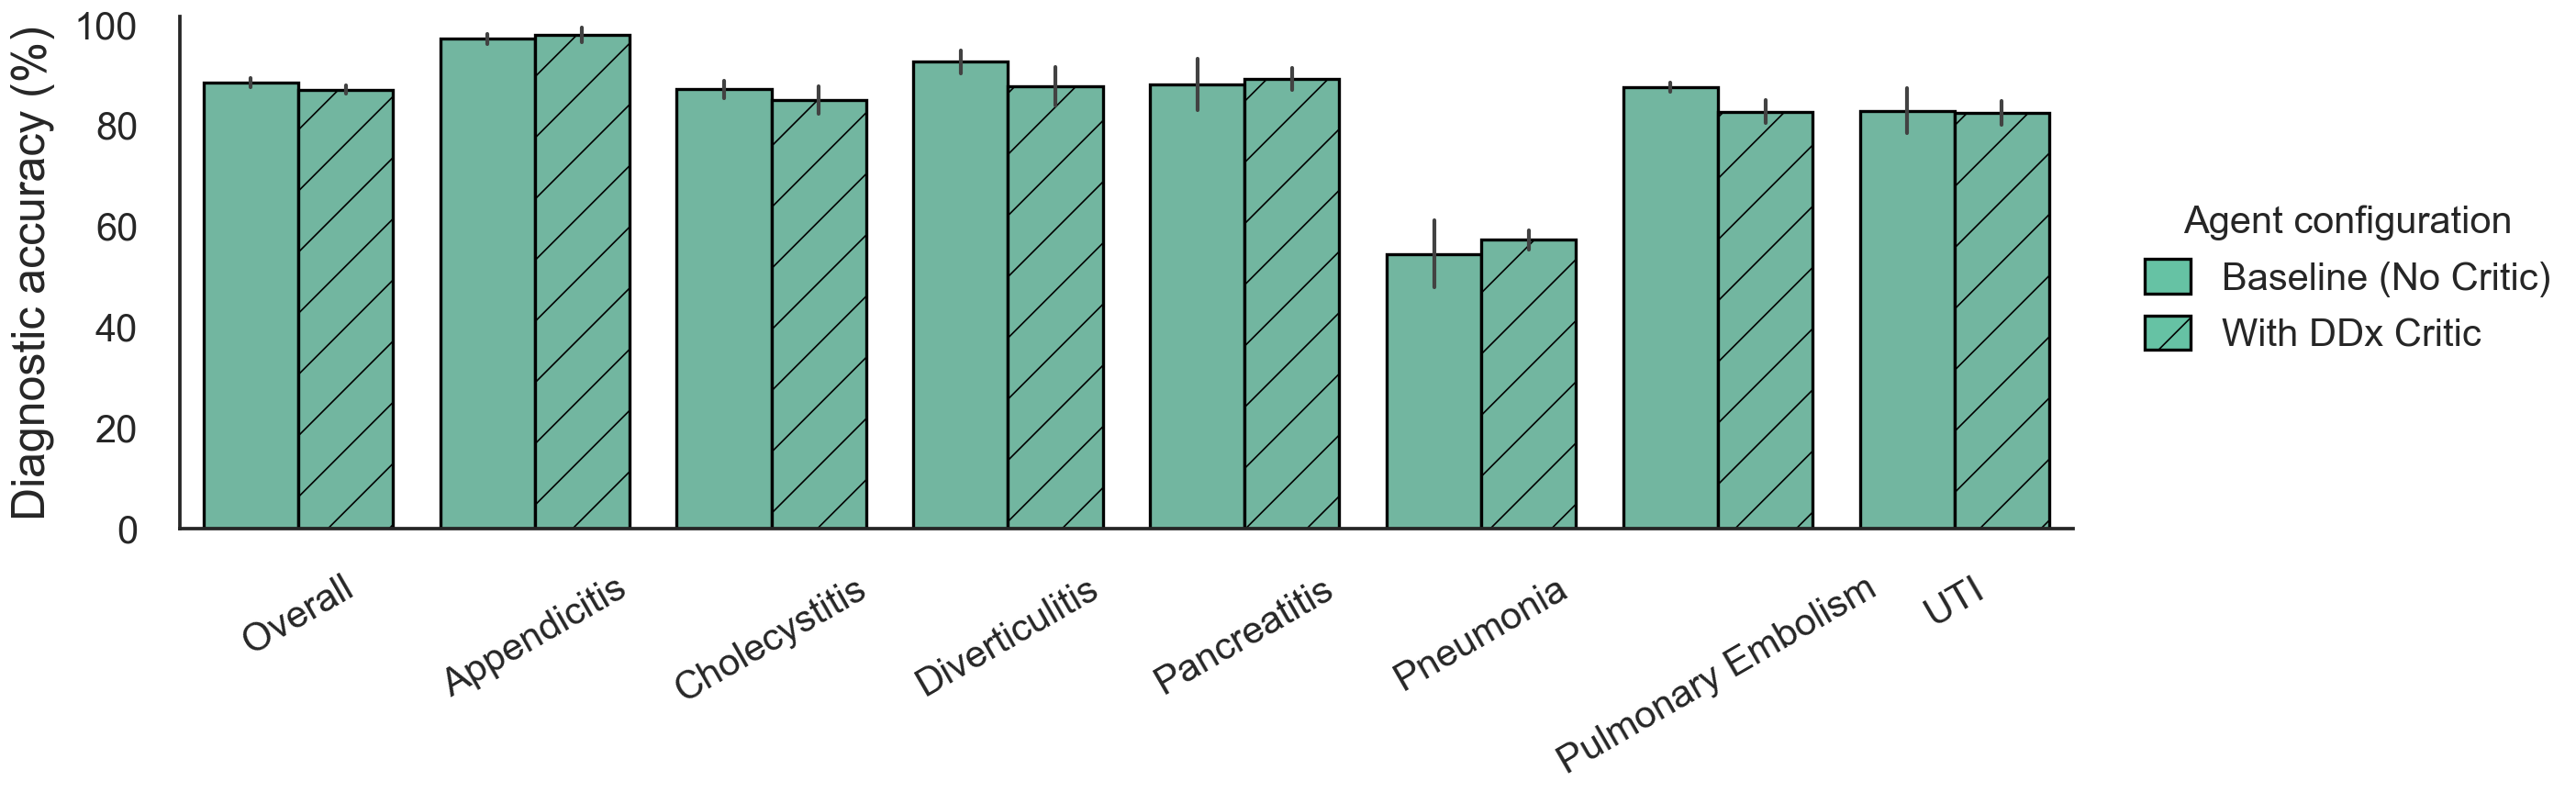

In [11]:
#  critic agent 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "Liberation Sans"],
    "font.size": 6,
    "axes.labelsize": 6,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "hatch.linewidth": 0.2,
    "legend.fontsize": 5,
    "legend.title_fontsize": 5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})


DATASET_NAME_MAP = {
    "appendicitis": "Appendicitis",
    "cholecystitis": "Cholecystitis",
    "diverticulitis": "Diverticulitis",
    "pancreatitis": "Pancreatitis",
    "pneumonia": "Pneumonia",
    "pulmonary_embolism": "Pulmonary Embolism",
    "uti": "UTI"
}
ALL_DATASETS = list(DATASET_NAME_MAP.keys())

PLOTS_BASE_DIR = '/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/56/56.10'
BASELINE_AGG_DIR = '/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/63/5runs/63.10'
CRITIC_AGG_DIR   = '/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/56/56.10'
NUM_RUNS_PER_CASE = 5


def load_and_process_experiment_data(agg_dir: str, model_label: str, datasets: list) -> pd.DataFrame:
    """
    加载一个实验（Baseline 或 Critic）的所有数据，返回每个数据集、每次 run 的平均诊断准确率。
    """
    all_runs_data = []

    # Individual disease datasets.
    for internal_name in datasets:
        agg_file_path = os.path.join(agg_dir, f"{internal_name}_multi_run.jsonl")
        if not os.path.exists(agg_file_path):
            print(f"  警告: 文件 {agg_file_path} 未找到，已跳过。")
            continue

        df_agg = pd.read_json(agg_file_path, lines=True)
        if df_agg.empty or 'runs' not in df_agg.columns:
            continue

        num_runs = len(df_agg['runs'].iloc[0]) if not df_agg.empty else 0

        for i in range(num_runs):
            df_agg[f'run_{i+1}_decision'] = df_agg['runs'].apply(
                lambda runs: runs[i]['decision'] if len(runs) > i else None
            )
            accuracy = df_agg[f'run_{i+1}_decision'].mean() * 100
            all_runs_data.append({
                'Dataset': DATASET_NAME_MAP[internal_name],
                'Accuracy': accuracy,
                'Run': i + 1,
                'Model': model_label,
            })

    # Overall
    all_agg_dfs = []
    for internal_name in ALL_DATASETS:
        agg_file_path = os.path.join(agg_dir, f"{internal_name}_multi_run.jsonl")
        if os.path.exists(agg_file_path):
            all_agg_dfs.append(pd.read_json(agg_file_path, lines=True))

    if all_agg_dfs:
        df_overall_agg = pd.concat(all_agg_dfs, ignore_index=True)
        num_runs_overall = len(df_overall_agg['runs'].iloc[0]) if not df_overall_agg.empty else 0
        for i in range(num_runs_overall):
            df_overall_agg[f'run_{i+1}_decision'] = df_overall_agg['runs'].apply(
                lambda runs: runs[i]['decision'] if len(runs) > i else None
            )
            accuracy = df_overall_agg[f'run_{i+1}_decision'].mean() * 100
            all_runs_data.append({
                'Dataset': 'Overall',
                'Accuracy': accuracy,
                'Run': i + 1,
                'Model': model_label,
            })

    return pd.DataFrame(all_runs_data)


print("--- Loading and Processing Data for Critic Ablation Study ---")
df_baseline = load_and_process_experiment_data(BASELINE_AGG_DIR, 'Baseline (No Critic)', ALL_DATASETS)
df_critic   = load_and_process_experiment_data(CRITIC_AGG_DIR,   'With DDx Critic',     ALL_DATASETS)

df_combined = pd.concat([df_baseline, df_critic], ignore_index=True)

# Control dataset order: Overall first, then the mapping order.
dataset_order = ['Overall'] + [
    name for name in DATASET_NAME_MAP.values()
    if name in df_combined['Dataset'].unique()
]
df_combined['Dataset'] = pd.Categorical(
    df_combined['Dataset'],
    categories=dataset_order,
    ordered=True
)
df_combined = df_combined.sort_values('Dataset')

# --- Plot ( Style) ---
fig, ax = plt.subplots(figsize=(150/25.4, 40/25.4), dpi=600)

# Axis style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

color_palette = {
    'Baseline (No Critic)': '#66c2a4',
    'With DDx Critic':      "#66c2a4" 
}
hue_order = ['Baseline (No Critic)', 'With DDx Critic']

# Main plot: grouped bar chart with error bars.
sns.barplot(
    data=df_combined,
    x='Dataset',
    y='Accuracy',
    hue='Model',
    hue_order=hue_order,
    palette=color_palette,
    errorbar='sd',
    capsize=0,
    err_kws={'linewidth': 0.5},
    ax=ax
)
bar_containers = ax.containers[:len(hue_order)]

for container, model in zip(bar_containers, hue_order):
    for patch in container.patches:
        patch.set_edgecolor("black")
        patch.set_linewidth(0.4)

        if model == "With DDx Critic":
            patch.set_hatch("///")
        else:
            patch.set_hatch("")


ax.set_xlabel('')
ax.tick_params(axis='x', labelrotation=30)
ax.set_ylabel('Diagnostic accuracy (%)')

# Start the y-axis near the minimum overall accuracy to avoid flattening the differences from zero.
min_acc = df_combined['Accuracy'].min()
# ax.set_ylim(max(0, min_acc - 3), 101.5)
ax.set_ylim(0, 101.5)

plt.xticks(rotation=30, ha='center')

# Add Critic - Baseline gain annotations to the bar chart.
grouped = df_combined.groupby(['Dataset', 'Model'])['Accuracy'].mean().unstack()

# Place a clean, frameless legend on the right.
import matplotlib.patches as mpatches

legend_handles = [
    mpatches.Patch(
        facecolor="#66c2a4",
        edgecolor="black",
        linewidth=0.4,
        label="Baseline (No Critic)"
    ),
    mpatches.Patch(
        facecolor="#66c2a4",
        edgecolor="black",
        linewidth=0.4,
        hatch="///",
        label="With DDx Critic"
    ),
]

ax.legend(
    handles=legend_handles,
    title="Agent configuration",
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.02, 0.7),
    handlelength=1.2,
    handleheight=1.0,
)


plt.tight_layout(rect=[0, 0, 0.82, 1])

os.makedirs(PLOTS_BASE_DIR, exist_ok=True)

summary_df = (
    df_combined
    .groupby(["Dataset", "Model"], observed=False)["Accuracy"]
    .agg(
        accuracy_mean="mean",
        accuracy_sd="std",
        n_runs="count",
    )
    .reset_index()
)

summary_df["accuracy_mean"] = summary_df["accuracy_mean"].round(3)
summary_df["accuracy_sd"] = summary_df["accuracy_sd"].round(3)

summary_path = os.path.join(PLOTS_BASE_DIR, "accuracy_ablation_critic_agent_summary.csv")
summary_df.to_csv(summary_path, index=False)
print(f"summary saved to: {summary_path}")

output_path_svg = os.path.join(PLOTS_BASE_DIR, 'accuracy_ablation_critic_agent.svg')
output_path_pdf = os.path.join(PLOTS_BASE_DIR, 'accuracy_ablation_critic_agent.pdf')
output_path_eps = os.path.join(PLOTS_BASE_DIR, 'accuracy_ablation_critic_agent.eps')
output_path_png = os.path.join(PLOTS_BASE_DIR, 'accuracy_ablation_critic_agent.png')

plt.savefig(output_path_svg, format="svg", bbox_inches='tight')
plt.savefig(output_path_pdf, format="pdf", bbox_inches='tight')
plt.savefig(output_path_eps, format="eps", bbox_inches='tight')
plt.savefig(output_path_png, format="png", bbox_inches='tight')
# plt.close()

print(f"消融研究对比图已保存到: {output_path_svg}")
